In [4]:
# ────────────────────────────────────────────────────────────────
#  Cell 1: Data loading, normalization + Improved Scaffold Split
# ────────────────────────────────────────────────────────────────

import torch
import torch.nn.functional as F
import numpy as np
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from collections import defaultdict
import random
from rdkit import Chem
from rdkit.Chem import AllChem

# Load dataset
tox21 = MoleculeNet(root='./data/MoleculeNet', name='Tox21')
print(f"Tox21: {len(tox21)} molecules | Node feats: {tox21.num_node_features}")

# Edge feature dimension
edge_dim = tox21[0].edge_attr.shape[1] if hasattr(tox21[0], 'edge_attr') and tox21[0].edge_attr is not None else 0
print(f"Edge features dim: {edge_dim}")

# ─── Feature normalization (same as before) ────────────────────────────────
all_x = torch.cat([d.x for d in tox21], dim=0).float()
mean_x, std_x = all_x.mean(dim=0), all_x.std(dim=0) + 1e-6

for d in tox21:
    d.x = ((d.x.float() - mean_x) / std_x).clamp(-10.0, 10.0)
    d.x = torch.nan_to_num(d.x, nan=0.0, posinf=0.0, neginf=0.0)

if edge_dim > 0:
    valid_edge_attrs = [d.edge_attr.float() for d in tox21 if hasattr(d, 'edge_attr') and d.edge_attr is not None]
    if valid_edge_attrs:
        all_edge = torch.cat(valid_edge_attrs, dim=0)
        mean_e, std_e = all_edge.mean(dim=0), all_edge.std(dim=0) + 1e-6
        for d in tox21:
            if hasattr(d, 'edge_attr') and d.edge_attr is not None:
                d.edge_attr = ((d.edge_attr.float() - mean_e) / std_e).clamp(-10.0, 10.0)
                d.edge_attr = torch.nan_to_num(d.edge_attr, nan=0.0, posinf=0.0, neginf=0.0)

# ─── Improved scaffold-based split ─────────────────────────────────────────
def get_scaffold_key(smiles: str, radius: int = 2, nBits: int = 2048):
    """Morgan fingerprint (ECFP-like) as scaffold proxy — hashable tuple"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return ("INVALID",)
    try:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
        return tuple(sorted(fp.GetOnBits()))   # sorted tuple → hashable & groupable
    except:
        return ("INVALID",)

scaffold_groups = defaultdict(list)

for idx, data in enumerate(tox21):
    key = get_scaffold_key(data.smiles)
    scaffold_groups[key].append(idx)

# Sort groups by size (largest first) — helps distribute bigger scaffolds first
sorted_groups = sorted(scaffold_groups.items(), key=lambda x: len(x[1]), reverse=True)

# Target sizes
n_total     = len(tox21)
train_size  = int(0.80 * n_total)   # ≈ 6264
val_size    = int(0.10 * n_total)   # ≈ 783
test_size   = n_total - train_size - val_size  # ≈ 784

train_idx = []
val_idx   = []
test_idx  = []

for _, indices in sorted_groups:
    if len(train_idx) < train_size:
        # Add whole group to train if possible
        if len(train_idx) + len(indices) <= train_size:
            train_idx.extend(indices)
        else:
            # Partial split of this scaffold group (rare, but possible)
            needed = train_size - len(train_idx)
            train_idx.extend(indices[:needed])
            remaining = indices[needed:]
            if remaining:
                if len(val_idx) < val_size:
                    val_idx.extend(remaining[:val_size - len(val_idx)])
                    remaining = remaining[val_size - len(val_idx):]
                if remaining:
                    test_idx.extend(remaining)
    elif len(val_idx) < val_size:
        if len(val_idx) + len(indices) <= val_size:
            val_idx.extend(indices)
        else:
            needed = val_size - len(val_idx)
            val_idx.extend(indices[:needed])
            test_idx.extend(indices[needed:])
    else:
        test_idx.extend(indices)

# ─── Fill any remaining slots (should be very few or zero) ────────────────
all_assigned = set(train_idx + val_idx + test_idx)
remaining = [i for i in range(n_total) if i not in all_assigned]

if remaining:
    random.shuffle(remaining)
    ptr = 0
    while len(train_idx) < train_size and ptr < len(remaining):
        train_idx.append(remaining[ptr])
        ptr += 1
    while len(val_idx) < val_size and ptr < len(remaining):
        val_idx.append(remaining[ptr])
        ptr += 1
    test_idx.extend(remaining[ptr:])

# Final shuffle inside each set
random.shuffle(train_idx)
random.shuffle(val_idx)
random.shuffle(test_idx)

# Create loaders
tox_train_loader = DataLoader([tox21[i] for i in train_idx], batch_size=32, shuffle=True)
tox_val_loader   = DataLoader([tox21[i] for i in val_idx],   batch_size=64, shuffle=False)
tox_test_loader  = DataLoader([tox21[i] for i in test_idx],  batch_size=64, shuffle=False)

# ─── Summary ───────────────────────────────────────────────────────────────
print(f"Improved scaffold split → train / val / test : "
      f"{len(train_idx)} / {len(val_idx)} / {len(test_idx)}")
print(f"Total assigned: {len(train_idx) + len(val_idx) + len(test_idx)} / {len(tox21)}")
print(f"Train fraction: {len(train_idx)/len(tox21):.3%}")
print(f"Val   fraction: {len(val_idx)/len(tox21):.3%}")
print(f"Test  fraction: {len(test_idx)/len(tox21):.3%}")
print(test_idx)

Tox21: 7831 molecules | Node feats: 9
Edge features dim: 3


[22:34:12] WARNING: not removing hydrogen atom without neighbors


Improved scaffold split → train / val / test : 6264 / 783 / 784
Total assigned: 7831 / 7831
Train fraction: 79.990%
Val   fraction: 9.999%
Test  fraction: 10.011%
[6992, 7202, 7618, 7499, 7825, 7288, 7752, 7287, 6976, 7181, 7589, 7045, 7627, 7599, 7340, 7689, 7418, 7152, 7473, 7338, 7327, 7782, 7280, 7518, 7246, 7165, 7816, 7609, 7144, 7380, 6975, 7316, 7066, 7341, 7104, 7359, 7482, 7654, 7081, 7519, 7580, 7096, 7395, 7628, 7058, 7409, 7209, 7657, 7299, 7083, 7452, 7258, 7241, 7439, 7587, 7808, 7313, 7738, 7552, 7820, 7151, 7786, 7428, 7827, 7698, 7767, 7158, 7668, 7514, 7735, 7282, 7262, 7682, 7647, 7542, 7331, 7759, 7050, 7435, 7136, 7399, 7570, 7138, 7242, 7525, 7524, 7610, 7386, 7200, 7586, 7777, 7103, 7479, 7049, 7385, 7133, 7644, 7672, 7617, 7492, 7649, 7111, 7177, 7678, 7441, 7118, 6989, 7675, 7201, 7476, 7655, 7595, 7308, 7442, 7141, 7005, 7169, 6987, 7464, 7730, 7352, 7624, 7302, 7784, 7266, 7319, 7583, 7354, 7554, 7564, 7146, 7731, 7105, 7475, 7204, 7775, 7210, 7410, 7339, 74

In [3]:
# ────────────────────────────────────────────────────────────────
#  Cell ~ Model (now 4 GINE layers)
# ────────────────────────────────────────────────────────────────

class BestTox21GNN(torch.nn.Module):
    def __init__(self, in_channels, edge_dim, hidden=256, num_tasks=12, dropout=0.25):
        super().__init__()

        def gin_mlp(in_dim, out_dim):
            return Sequential(
                Linear(in_dim, out_dim),
                ReLU(),
                Linear(out_dim, out_dim)
            )

        self.conv1 = GINEConv(gin_mlp(in_channels, hidden), edge_dim=edge_dim)
        self.bn1   = BatchNorm(hidden)

        self.conv2 = GINEConv(gin_mlp(hidden, hidden), edge_dim=edge_dim)
        self.bn2   = BatchNorm(hidden)

        self.conv3 = GINEConv(gin_mlp(hidden, hidden), edge_dim=edge_dim)
        self.bn3   = BatchNorm(hidden)

        self.conv4 = GINEConv(gin_mlp(hidden, hidden), edge_dim=edge_dim)
        self.bn4   = BatchNorm(hidden)

        self.lin1 = Linear(hidden * 2, hidden)
        self.lin2 = Linear(hidden, num_tasks)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x.float().clamp(-10,10),
            data.edge_index,
            data.edge_attr.float() if hasattr(data, 'edge_attr') and data.edge_attr is not None else None,
            data.batch
        )

        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_attr)))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_attr)))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.relu(self.bn3(self.conv3(x, edge_index, edge_attr)))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.relu(self.bn4(self.conv4(x, edge_index, edge_attr)))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x_mean = global_mean_pool(x, batch)
        x_sum  = global_add_pool(x, batch)
        x_pool = torch.cat([x_mean, x_sum], dim=-1)

        x = F.relu(self.lin1(x_pool))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin2(x).clamp(-10, 10)

In [4]:
# ────────────────────────────────────────────────────────────────
#  Cell ~ Model, optimizer, scheduler
# ────────────────────────────────────────────────────────────────

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BestTox21GNN(
    in_channels=tox21.num_node_features,
    edge_dim=edge_dim,
    hidden=256,
    num_tasks=12,
    dropout=0.25
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)

# Cosine annealing with warm restarts (good for longer training)
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,          # first cycle 10 epochs
    T_mult=2,        # double cycle length after each restart
    eta_min=1e-6
)

# Also keep ReduceLROnPlateau as fallback / monitoring
plateau_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.7, patience=5, min_lr=1e-6
)

print(f"Model ready — {sum(p.numel() for p in model.parameters()):,} params")

Model ready — 602,672 params


In [5]:
# ────────────────────────────────────────────────────────────────
#  Cell ~ pos_weight + criterion  (unchanged)
# ────────────────────────────────────────────────────────────────

pos_weights = []
for t in range(12):
    y_all = torch.cat([d.y[:, t] for d in tox21], dim=0)
    valid = (~torch.isnan(y_all)) & (y_all != -1)
    pos = (y_all[valid] == 1).sum().float()
    neg = (y_all[valid] == 0).sum().float()
    pos_weights.append(neg / pos.clamp(min=1e-6))

pos_weight = torch.tensor(pos_weights).to(device)
print("Pos weights:", [f"{w:.2f}" for w in pos_weight])

criterion = torch.nn.BCEWithLogitsLoss(reduction='none', pos_weight=pos_weight)

Pos weights: ['22.51', '27.51', '7.53', '18.40', '6.81', '18.87', '33.68', '5.19', '25.79', '16.38', '5.33', '15.01']


In [6]:
# ────────────────────────────────────────────────────────────────
#  Cell ~ train / eval  (using validation set now)
# ────────────────────────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, epoch):
    model.train()
    total_loss = 0.0
    n = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch)

        y = batch.y
        mask = (~torch.isnan(y)) & (y != -1)
        cnt = mask.sum().clamp(min=1)
        target = torch.where(mask, y.float(), torch.zeros_like(y.float()))

        loss = (criterion(logits, target) * mask.float()).sum() / cnt

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        n += batch.num_graphs

    return total_loss / n if n > 0 else float('nan')


@torch.no_grad()
def evaluate(model, loader, name="Val"):
    model.eval()
    all_logits, all_y = [], []
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        all_logits.append(logits.cpu())
        all_y.append(batch.y.cpu())

    logits = torch.cat(all_logits).numpy()
    y      = torch.cat(all_y).numpy()

    aucs = []
    for t in range(12):
        valid = (~np.isnan(y[:,t])) & (y[:,t] != -1)
        if valid.sum() < 10:
            aucs.append(np.nan)
            continue
        aucs.append(roc_auc_score(y[valid,t], logits[valid,t]))

    macro = np.nanmean(aucs)
    print(f"{name} Macro-AUC: {macro:.4f}  ({sum(~np.isnan(aucs))}/12 tasks)")
    return macro

Val Macro-AUC: 0.6695  (12/12 tasks)
Epoch  1 | train loss 1.28792 | val AUC 0.6695 | LR 4.88e-04 ← new best
Val Macro-AUC: 0.6766  (12/12 tasks)
Epoch  2 | train loss 1.14719 | val AUC 0.6766 | LR 4.52e-04 ← new best
Val Macro-AUC: 0.6988  (12/12 tasks)
Epoch  3 | train loss 1.13347 | val AUC 0.6988 | LR 3.97e-04 ← new best
Val Macro-AUC: 0.7195  (12/12 tasks)
Epoch  4 | train loss 1.11420 | val AUC 0.7195 | LR 3.28e-04 ← new best
Val Macro-AUC: 0.7076  (12/12 tasks)
Epoch  5 | train loss 1.09988 | val AUC 0.7076 | LR 2.51e-04
Val Macro-AUC: 0.7341  (12/12 tasks)
Epoch  6 | train loss 1.07850 | val AUC 0.7341 | LR 1.73e-04 ← new best
Val Macro-AUC: 0.7281  (12/12 tasks)
Epoch  7 | train loss 1.06761 | val AUC 0.7281 | LR 1.04e-04
Val Macro-AUC: 0.7412  (12/12 tasks)
Epoch  8 | train loss 1.04821 | val AUC 0.7412 | LR 4.87e-05 ← new best
Val Macro-AUC: 0.7535  (12/12 tasks)
Epoch  9 | train loss 1.04130 | val AUC 0.7535 | LR 1.32e-05 ← new best
Val Macro-AUC: 0.7578  (12/12 tasks)
Epoc

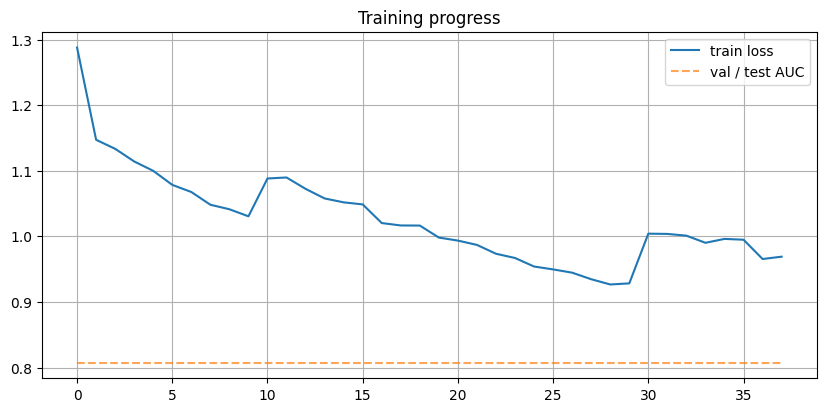

In [7]:
# ────────────────────────────────────────────────────────────────
#  Cell ~ Training loop (50 epochs + val monitoring)
# ────────────────────────────────────────────────────────────────

max_epochs = 50
best_val_auc = -1
patience_counter = 0
train_losses = []
val_aucs = []

for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(model, tox_train_loader, optimizer, epoch)
    train_losses.append(train_loss)

    val_auc = evaluate(model, tox_val_loader, "Val")

    # Step schedulers
    scheduler.step()                       # CosineAnnealingWarmRestarts
    plateau_scheduler.step(val_auc)        # Reduce on plateau (backup)

    current_lr = optimizer.param_groups[0]['lr']

    mark = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), "best_model_scaffold.pt")
        mark = " ← new best"
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"Epoch {epoch:2d} | train loss {train_loss:.5f} | val AUC {val_auc:.4f} | LR {current_lr:.2e}{mark}")

    if patience_counter >= 8:
        print("Early stopping triggered")
        break

# Final test evaluation
model.load_state_dict(torch.load("best_model_scaffold.pt"))
test_auc = evaluate(model, tox_test_loader, "Test (best model)")
print(f"\nFinal test Macro-AUC (scaffold split): {test_auc:.4f}")

plt.figure(figsize=(10,4.5))
plt.plot(train_losses, label='train loss')
plt.plot(val_aucs + [test_auc]* (len(train_losses)-len(val_aucs)), '--', label='val / test AUC', alpha=0.7)
plt.legend(); plt.grid(True); plt.title("Training progress"); plt.show()

In [8]:
# ────────────────────────────────────────────────────────────────
#  Cell: Load best model + Evaluation on Val and Test
# ────────────────────────────────────────────────────────────────

import torch
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Load the best saved model
model.load_state_dict(torch.load("best_model_scaffold.pt", map_location=device))
model.eval()
print("Best scaffold-trained model loaded.")

# ─── Evaluation function that returns both macro AUC and per-task AUCs ──────
@torch.no_grad()
def evaluate_detailed(loader, name="Set"):
    model.eval()
    all_logits = []
    all_labels = []
    
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        all_logits.append(logits.cpu())
        all_labels.append(batch.y.cpu())
    
    logits_np = torch.cat(all_logits).numpy()
    labels_np = torch.cat(all_labels).numpy()
    
    task_aucs = []
    task_names = [
        'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
        'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
    ]
    
    for t in range(12):
        valid = (~np.isnan(labels_np[:, t])) & (labels_np[:, t] != -1)
        if valid.sum() < 10:
            task_aucs.append(np.nan)
            continue
        auc = roc_auc_score(labels_np[valid, t], logits_np[valid, t])
        task_aucs.append(auc)
    
    macro_auc = np.nanmean(task_aucs)
    n_valid = sum(~np.isnan(task_aucs))
    
    print(f"\n{name} Evaluation:")
    print(f"  Macro-AUC: {macro_auc:.4f}  ({n_valid}/12 tasks)")
    print("\nPer-task AUC:")
    for name, auc in zip(task_names, task_aucs):
        print(f"  {name:12} : {auc:.4f}" if not np.isnan(auc) else f"  {name:12} : N/A")
    
    return macro_auc, task_aucs, task_names

Best scaffold-trained model loaded.


In [9]:
# ────────────────────────────────────────────────────────────────
#  Cell: Run evaluation on Val and Test + print detailed results
# ────────────────────────────────────────────────────────────────

print("Evaluating on Validation set...")
val_macro, val_per_task, task_names = evaluate_detailed(tox_val_loader, "Validation")

print("\n" + "="*60 + "\n")

print("Evaluating on Test set...")
test_macro, test_per_task, _ = evaluate_detailed(tox_test_loader, "Test")

print(f"\nFinal summary:")
print(f"  Val   macro-AUC: {val_macro:.4f}")
print(f"  Test  macro-AUC: {test_macro:.4f}")

Evaluating on Validation set...

Validation Evaluation:
  Macro-AUC: 0.7908  (12/12 tasks)

Per-task AUC:
  NR-AR        : 0.7855
  NR-AR-LBD    : 0.7662
  NR-AhR       : 0.8011
  NR-Aromatase : 0.7164
  NR-ER        : 0.7149
  NR-ER-LBD    : 0.7755
  NR-PPAR-gamma : 0.8022
  SR-ARE       : 0.8050
  SR-ATAD5     : 0.8572
  SR-HSE       : 0.7850
  SR-MMP       : 0.8413
  SR-p53       : 0.8397


Evaluating on Test set...

Test Evaluation:
  Macro-AUC: 0.8076  (12/12 tasks)

Per-task AUC:
  NR-AR        : 0.8317
  NR-AR-LBD    : 0.8777
  NR-AhR       : 0.8758
  NR-Aromatase : 0.8347
  NR-ER        : 0.7258
  NR-ER-LBD    : 0.7886
  NR-PPAR-gamma : 0.7637
  SR-ARE       : 0.7655
  SR-ATAD5     : 0.8044
  SR-HSE       : 0.7548
  SR-MMP       : 0.8576
  SR-p53       : 0.8108

Final summary:
  Val   macro-AUC: 0.7908
  Test  macro-AUC: 0.8076


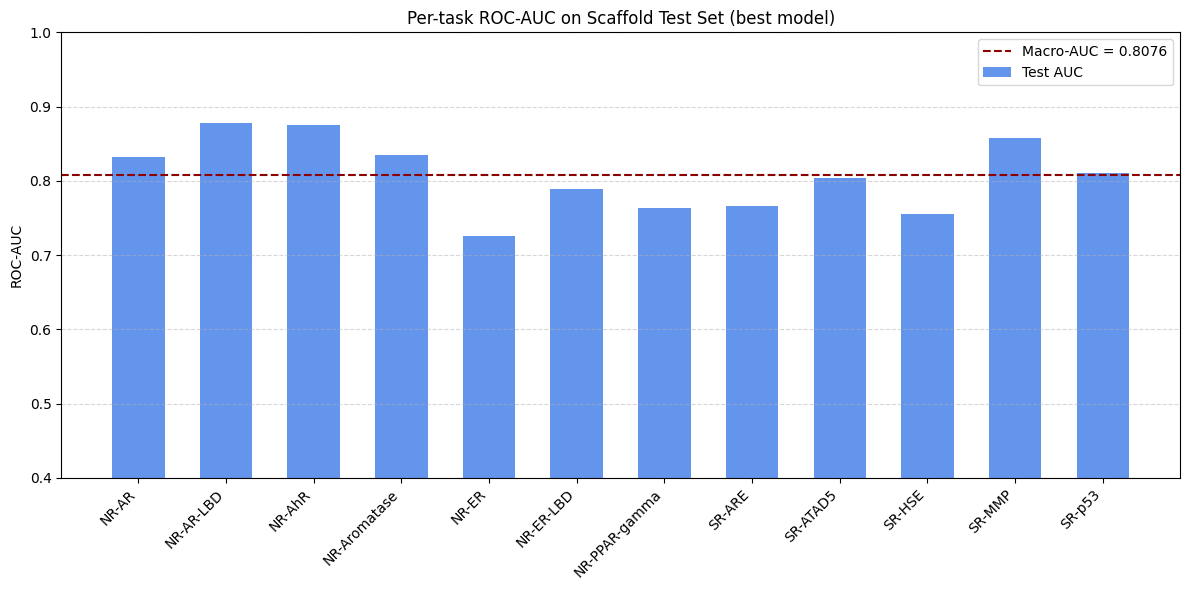

In [10]:
# ────────────────────────────────────────────────────────────────
#  Cell: Bar plot — Per-task AUC on Test set
# ────────────────────────────────────────────────────────────────

plt.figure(figsize=(12, 6))

x = np.arange(len(task_names))
width = 0.6

plt.bar(x, test_per_task, width, color='cornflowerblue', label='Test AUC')

plt.axhline(y=test_macro, color='darkred', linestyle='--', linewidth=1.5,
            label=f'Macro-AUC = {test_macro:.4f}')

plt.xticks(x, task_names, rotation=45, ha='right', fontsize=10)
plt.ylabel('ROC-AUC')
plt.title('Per-task ROC-AUC on Scaffold Test Set (best model)')
plt.ylim(0.4, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

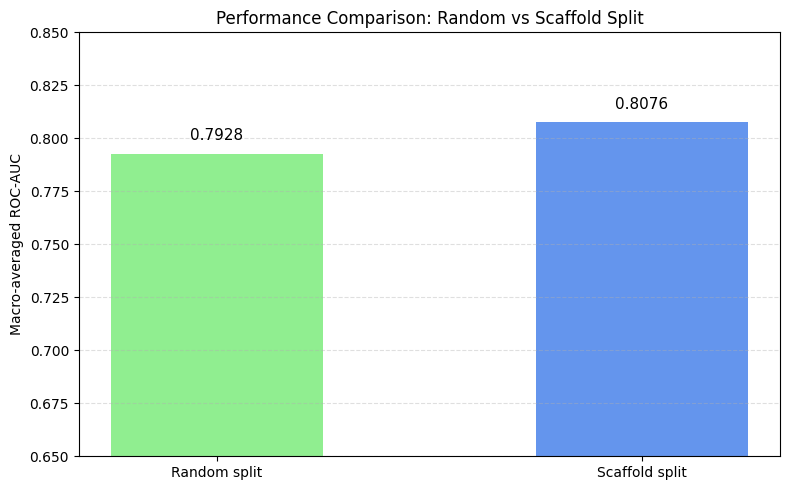

In [11]:
# ────────────────────────────────────────────────────────────────
#  Cell: Comparison bar chart — Random vs Scaffold split
# ────────────────────────────────────────────────────────────────

# Replace with your actual best random-split macro-AUC from earlier run
random_split_macro = 0.7928   # ← CHANGE THIS to your real number from random split

plt.figure(figsize=(8, 5))

splits = ['Random split', 'Scaffold split']
auc_values = [random_split_macro, test_macro]

bars = plt.bar(splits, auc_values, color=['lightgreen', 'cornflowerblue'], width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}',
             ha='center', va='bottom', fontsize=11)

plt.ylabel('Macro-averaged ROC-AUC')
plt.title('Performance Comparison: Random vs Scaffold Split')
plt.ylim(0.65, 0.85)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

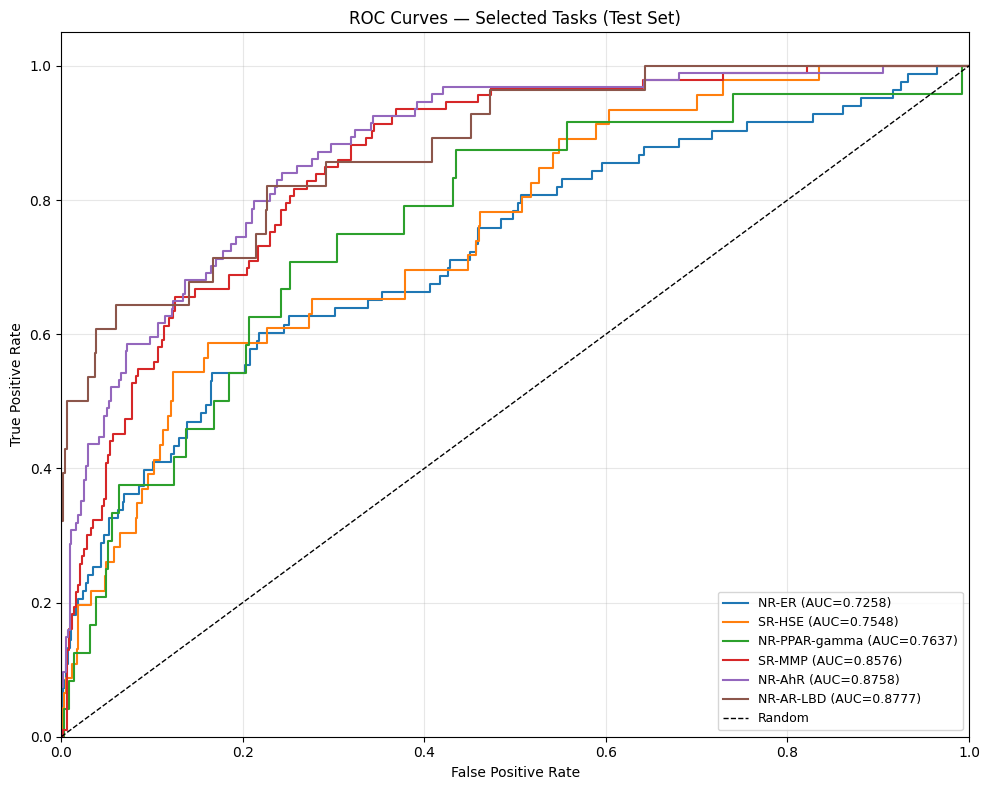

In [12]:
# ────────────────────────────────────────────────────────────────
#  Cell: ROC curves for selected tasks (example: top 4 and bottom 4)
# ────────────────────────────────────────────────────────────────

# Run evaluation again to get logits & labels (or save them earlier)
# Here we re-compute on test set for simplicity

all_logits = []
all_labels = []

with torch.no_grad():
    for batch in tox_test_loader:
        batch = batch.to(device)
        logits = model(batch)
        all_logits.append(logits.cpu())
        all_labels.append(batch.y.cpu())

logits_np = torch.cat(all_logits).numpy()
labels_np = torch.cat(all_labels).numpy()

# Choose tasks to plot (e.g. best and worst performing)
task_indices = np.argsort(test_per_task)
selected_tasks = list(task_indices[:3]) + list(task_indices[-3:])   # 3 worst + 3 best

plt.figure(figsize=(10, 8))

for t in selected_tasks:
    valid = (~np.isnan(labels_np[:, t])) & (labels_np[:, t] != -1)
    if valid.sum() < 10:
        continue
    
    fpr, tpr, _ = roc_curve(labels_np[valid, t], logits_np[valid, t])
    plt.plot(fpr, tpr, label=f"{task_names[t]} (AUC={test_per_task[t]:.4f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Selected Tasks (Test Set)')
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# ────────────────────────────────────────────────────────────────
#  GCN Model for Tox21 (4 layers, same structure as your GINE/GAT)
# ────────────────────────────────────────────────────────────────

from torch_geometric.nn import GCNConv, BatchNorm

class GCNTox21(torch.nn.Module):
    def __init__(self, in_channels, hidden=256, num_tasks=12, dropout=0.25):
        super().__init__()
        
        self.conv1 = GCNConv(in_channels, hidden)
        self.bn1   = BatchNorm(hidden)
        
        self.conv2 = GCNConv(hidden, hidden)
        self.bn2   = BatchNorm(hidden)
        
        self.conv3 = GCNConv(hidden, hidden)
        self.bn3   = BatchNorm(hidden)
        
        self.conv4 = GCNConv(hidden, hidden)
        self.bn4   = BatchNorm(hidden)

        self.lin1 = torch.nn.Linear(hidden * 2, hidden)
        self.lin2 = torch.nn.Linear(hidden, num_tasks)
        self.dropout = dropout

    def forward(self, data):
        x = data.x.float().clamp(-10, 10)
        edge_index = data.edge_index
        batch = data.batch

        # GCNConv uses edge_index only (no edge_attr)
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.relu(self.bn4(self.conv4(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x_mean = global_mean_pool(x, batch)
        x_sum  = global_add_pool(x, batch)
        x_pool = torch.cat([x_mean, x_sum], dim=-1)

        x = F.relu(self.lin1(x_pool))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin2(x).clamp(-10, 10)

In [14]:
# ────────────────────────────────────────────────────────────────
#  Instantiate GCN, optimizer, schedulers (same as before)
# ────────────────────────────────────────────────────────────────

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_gcn = GCNTox21(
    in_channels=tox21.num_node_features,   # 9
    hidden=256,
    num_tasks=12,
    dropout=0.25
).to(device)

optimizer = torch.optim.Adam(model_gcn.parameters(), lr=5e-4, weight_decay=1e-5)

# Same schedulers as your previous runs
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, ReduceLROnPlateau

scheduler_cosine = CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

scheduler_plateau = ReduceLROnPlateau(
    optimizer, mode='max', factor=0.7, patience=5, min_lr=1e-6
)

print(f"GCN model ready — {sum(p.numel() for p in model_gcn.parameters()):,} params")

GCN model ready — 336,396 params


In [15]:
# ────────────────────────────────────────────────────────────────
#  Training & Evaluation (same as before)
# ────────────────────────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, epoch):
    model.train()
    total_loss = 0.0
    n = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch)

        y = batch.y
        mask = (~torch.isnan(y)) & (y != -1)
        cnt = mask.sum().clamp(min=1)
        target = torch.where(mask, y.float(), torch.zeros_like(y.float()))

        loss = (criterion(logits, target) * mask.float()).sum() / cnt

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        n += batch.num_graphs

    return total_loss / n if n > 0 else float('nan')


@torch.no_grad()
def evaluate(model, loader, name="Val"):
    model.eval()
    all_logits, all_y = [], []
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        all_logits.append(logits.cpu())
        all_y.append(batch.y.cpu())

    logits = torch.cat(all_logits).numpy()
    y      = torch.cat(all_y).numpy()

    aucs = []
    for t in range(12):
        valid = (~np.isnan(y[:,t])) & (y[:,t] != -1)
        if valid.sum() < 10:
            aucs.append(np.nan)
            continue
        aucs.append(roc_auc_score(y[valid,t], logits[valid,t]))

    macro = np.nanmean(aucs)
    print(f"{name} Macro-AUC: {macro:.4f}  ({sum(~np.isnan(aucs))}/12 tasks)")
    return macro

In [16]:
# ────────────────────────────────────────────────────────────────
#  Train GCN on Tox21 scaffold split
# ────────────────────────────────────────────────────────────────

max_epochs = 50
best_val_auc = -1
patience_counter = 0
train_losses_gcn = []
val_aucs_gcn = []

for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(model_gcn, tox_train_loader, optimizer, epoch)
    train_losses_gcn.append(train_loss)

    val_auc = evaluate(model_gcn, tox_val_loader, "Val")

    scheduler_cosine.step()
    scheduler_plateau.step(val_auc)

    current_lr = optimizer.param_groups[0]['lr']

    mark = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model_gcn.state_dict(), "best_gcn_tox21_scaffold.pt")
        mark = " ← new best"
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"Epoch {epoch:2d} | train loss {train_loss:.5f} | val AUC {val_auc:.4f} | LR {current_lr:.2e}{mark}")

    if patience_counter >= 8:
        print("Early stopping triggered")
        break

# Final test
model_gcn.load_state_dict(torch.load("best_gcn_tox21_scaffold.pt"))
test_auc_gcn = evaluate(model_gcn, tox_test_loader, "Test (best GCN model)")
print(f"\nFinal GCN test Macro-AUC (scaffold split): {test_auc_gcn:.4f}")

Val Macro-AUC: 0.6708  (12/12 tasks)
Epoch  1 | train loss 1.29374 | val AUC 0.6708 | LR 4.88e-04 ← new best
Val Macro-AUC: 0.7167  (12/12 tasks)
Epoch  2 | train loss 1.13016 | val AUC 0.7167 | LR 4.52e-04 ← new best
Val Macro-AUC: 0.7525  (12/12 tasks)
Epoch  3 | train loss 1.08315 | val AUC 0.7525 | LR 3.97e-04 ← new best
Val Macro-AUC: 0.7548  (12/12 tasks)
Epoch  4 | train loss 1.06212 | val AUC 0.7548 | LR 3.28e-04 ← new best
Val Macro-AUC: 0.7629  (12/12 tasks)
Epoch  5 | train loss 1.02857 | val AUC 0.7629 | LR 2.51e-04 ← new best
Val Macro-AUC: 0.7750  (12/12 tasks)
Epoch  6 | train loss 1.00265 | val AUC 0.7750 | LR 1.73e-04 ← new best
Val Macro-AUC: 0.7763  (12/12 tasks)
Epoch  7 | train loss 0.97987 | val AUC 0.7763 | LR 1.04e-04 ← new best
Val Macro-AUC: 0.7749  (12/12 tasks)
Epoch  8 | train loss 0.96345 | val AUC 0.7749 | LR 4.87e-05
Val Macro-AUC: 0.7784  (12/12 tasks)
Epoch  9 | train loss 0.95200 | val AUC 0.7784 | LR 1.32e-05 ← new best
Val Macro-AUC: 0.7799  (12/12 

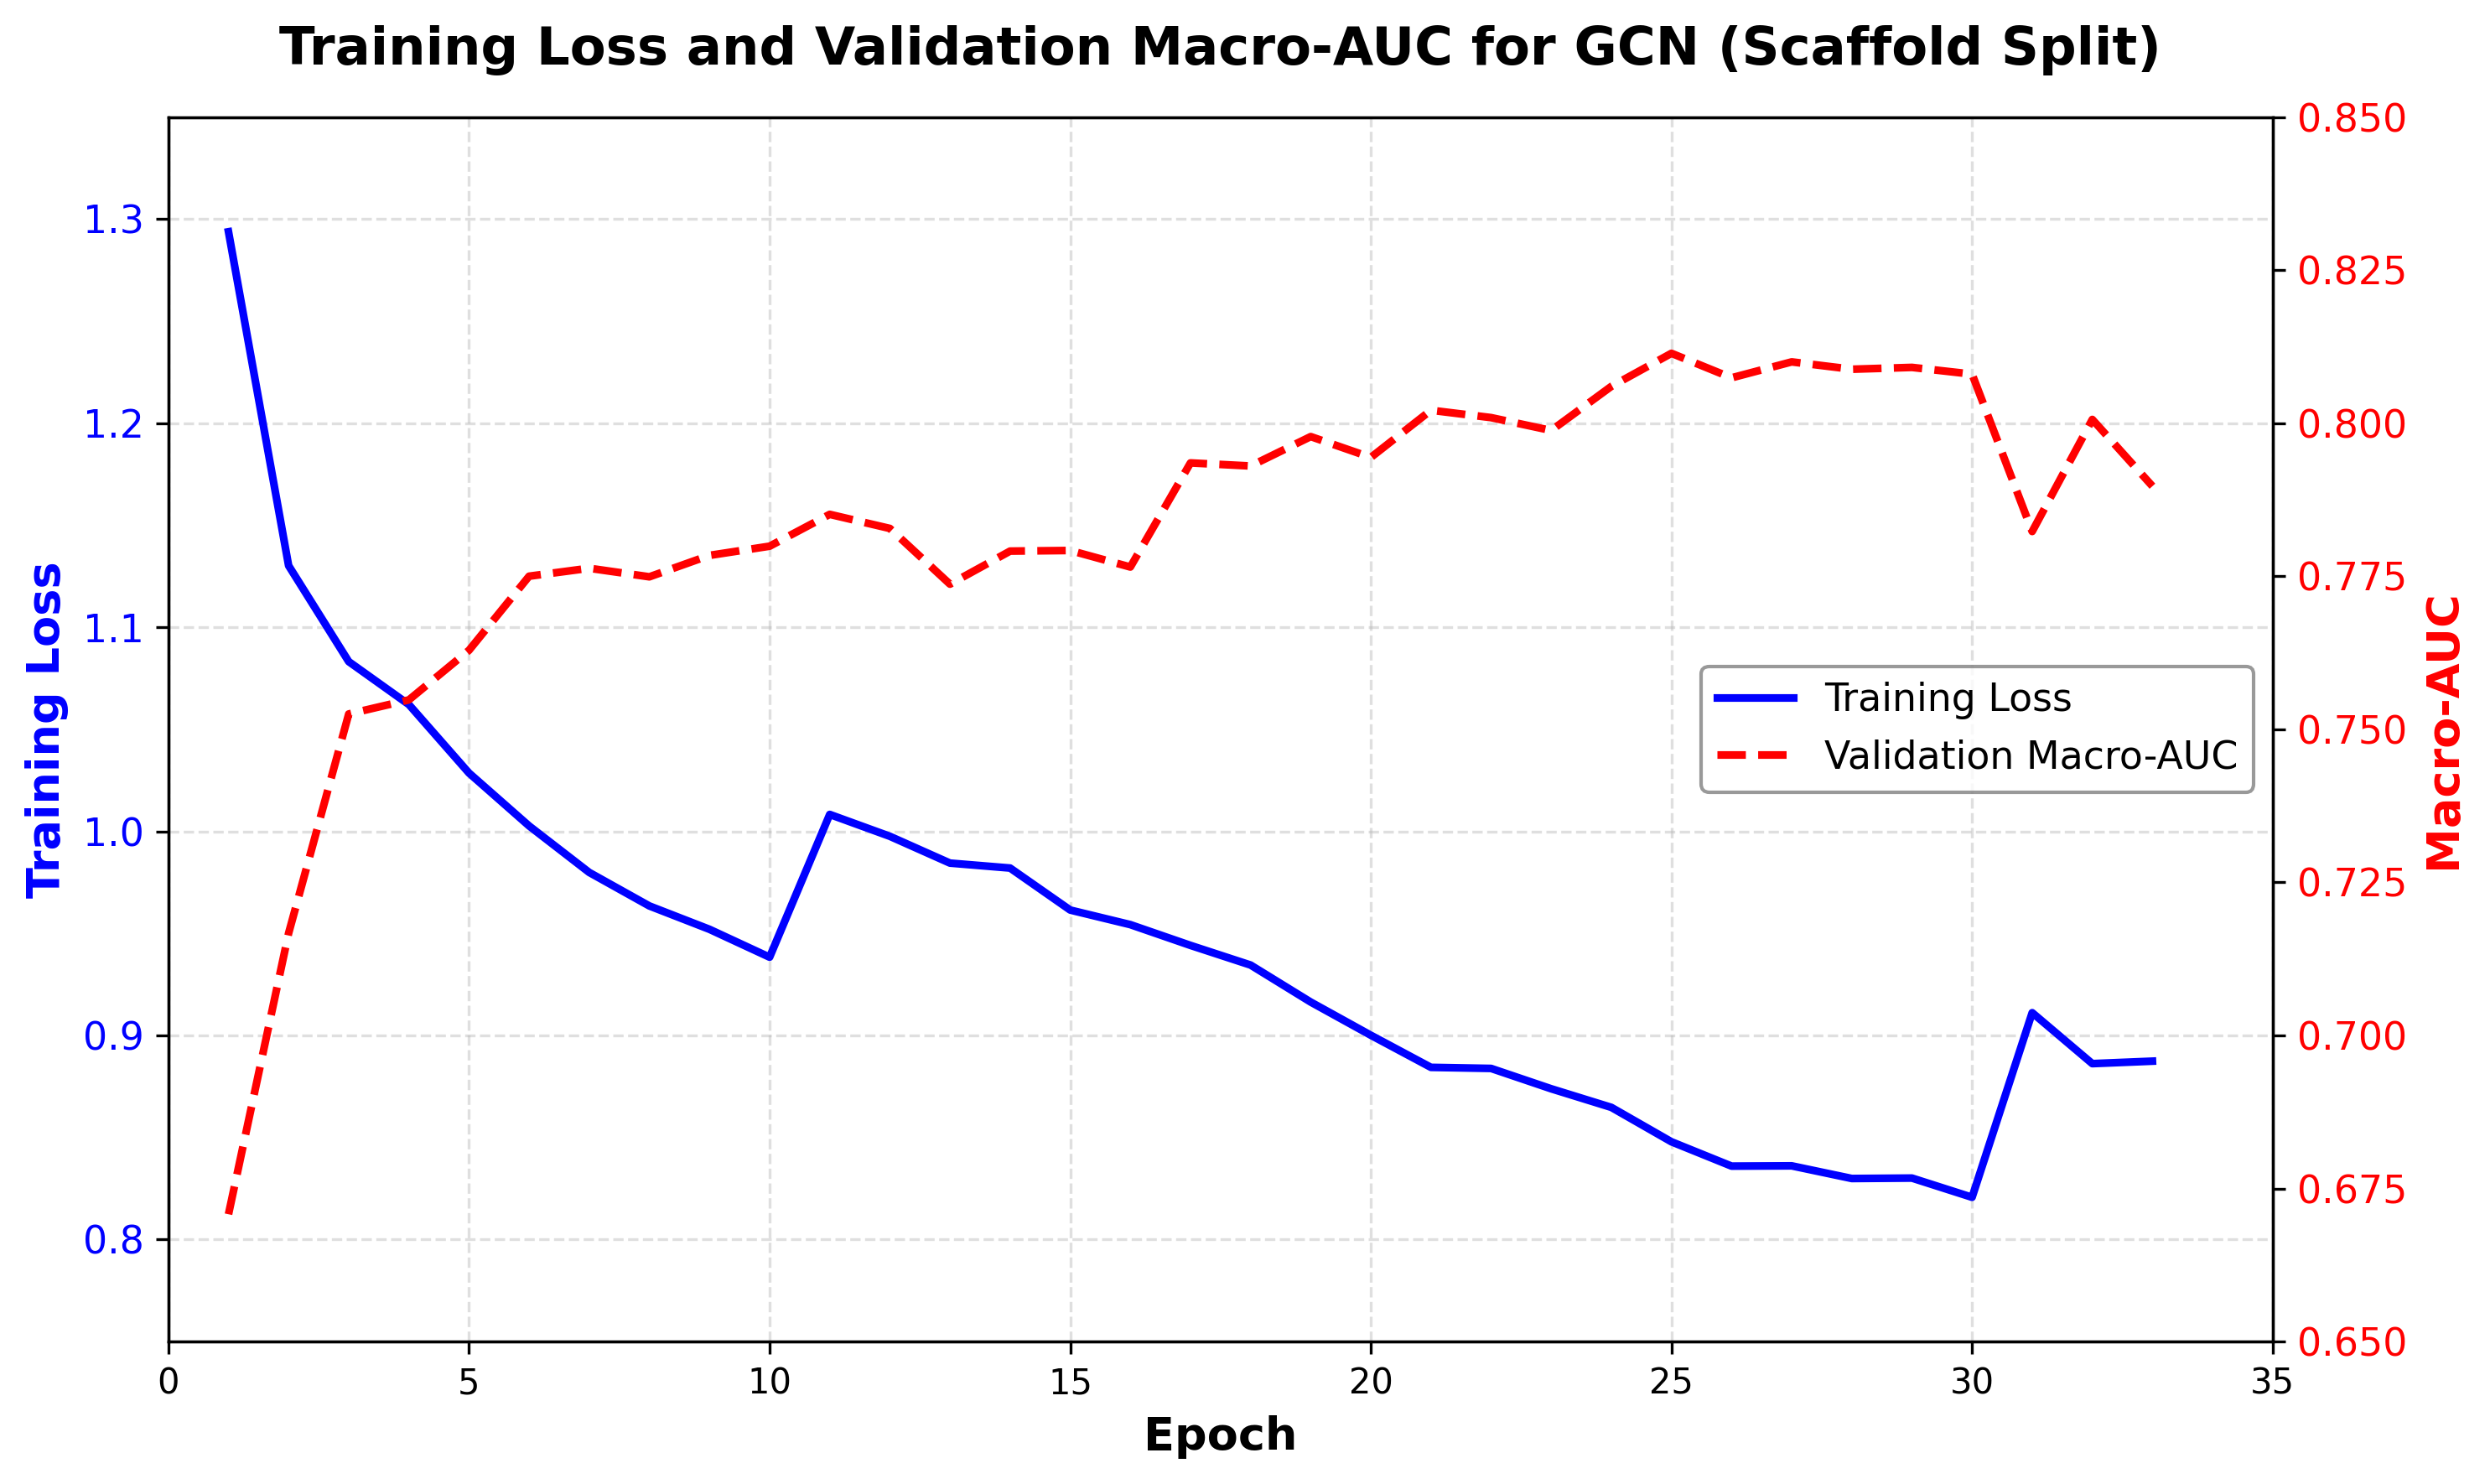

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# === Paste your actual training data here ===
# These are copied from the logs you provided

epochs = list(range(1, 34))  # up to epoch 33 (early stopping triggered)

train_losses = [
    1.29374, 1.13016, 1.08315, 1.06212, 1.02857,
    1.00265, 0.97987, 0.96345, 0.95200, 0.93834,
    1.00828, 0.99757, 0.98444, 0.98201, 0.96144,
    0.95429, 0.94412, 0.93449, 0.91636, 0.90010,
    0.88436, 0.88384, 0.87387, 0.86476, 0.84790,
    0.83598, 0.83611, 0.82991, 0.83012, 0.82071,
    0.91114, 0.88619, 0.88740
]

val_aucs = [
    0.6708, 0.7167, 0.7525, 0.7548, 0.7629,
    0.7750, 0.7763, 0.7749, 0.7784, 0.7799,
    0.7851, 0.7828, 0.7737, 0.7791, 0.7792,
    0.7765, 0.7935, 0.7930, 0.7978, 0.7944,
    0.8021, 0.8009, 0.7988, 0.8060, 0.8114,
    0.8074, 0.8100, 0.8088, 0.8091, 0.8080,
    0.7823, 0.8006, 0.7897
]

# === Plotting code starts here ===

plt.figure(figsize=(10, 6), dpi=300)  # High resolution for paper

# Training loss (left y-axis, solid line)
ax1 = plt.gca()
ax1.plot(epochs, train_losses, 'b-', linewidth=2.2, label='Training Loss')
ax1.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax1.set_ylabel('Training Loss', color='blue', fontsize=13, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='blue', labelsize=11)
ax1.grid(True, linestyle='--', alpha=0.4)

# Validation AUC (right y-axis, dashed line)
ax2 = ax1.twinx()
ax2.plot(epochs, val_aucs, 'r--', linewidth=2.2, label='Validation Macro-AUC')
ax2.set_ylabel('Macro-AUC', color='red', fontsize=13, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red', labelsize=11)

# Title and legend
plt.title('Training Loss and Validation Macro-AUC for GCN (Scaffold Split)',
          fontsize=15, fontweight='bold', pad=15)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right',
           fontsize=11, frameon=True, edgecolor='gray')

# Limits and ticks
ax1.set_xlim(0, 35)
ax1.set_ylim(0.75, 1.35)
ax2.set_ylim(0.65, 0.85)

# Make it publication-ready
plt.tight_layout()

# Save as high-quality PNG for paper
plt.savefig('figure_4_6_gcn_training_curves.png', dpi=300, bbox_inches='tight')

# Also show on screen (optional)
plt.show()

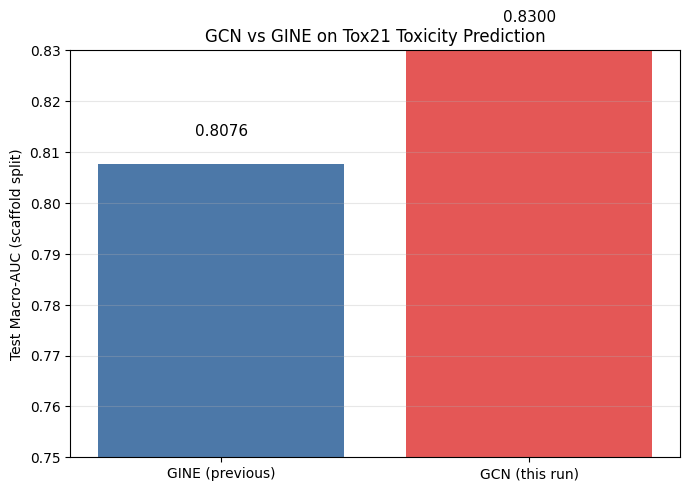

In [17]:
# ────────────────────────────────────────────────────────────────
#  GCN vs GINE Comparison Plot
# ────────────────────────────────────────────────────────────────

# Update these with your real numbers
gine_test_auc = 0.8076          # your previous best
gcn_test_auc  = test_auc_gcn    # from the line above

plt.figure(figsize=(7, 5))

models = ['GINE (previous)', 'GCN (this run)']
aucs   = [gine_test_auc, gcn_test_auc]

bars = plt.bar(models, aucs, color=['#4c78a8', '#e45756'])
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.005, f'{y:.4f}', 
             ha='center', va='bottom', fontsize=11)

plt.ylabel('Test Macro-AUC (scaffold split)')
plt.title('GCN vs GINE on Tox21 Toxicity Prediction')
plt.ylim(0.75, 0.83)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("gcn_vs_gine_tox21_comparison.png", dpi=150)
plt.show()

In [18]:
# ────────────────────────────────────────────────────────────────
#  GATv2 Model for Tox21 (4 layers, same structure as GCN/GINE)
# ────────────────────────────────────────────────────────────────

from torch_geometric.nn import GATv2Conv, BatchNorm

class GATv2Tox21(torch.nn.Module):
    def __init__(self, in_channels, hidden=256, num_tasks=12, dropout=0.3, heads=4):
        super().__init__()
        
        # GATv2 layers – note: concat=True doubles the output dim per layer
        self.conv1 = GATv2Conv(in_channels, hidden // heads, heads=heads, concat=True, dropout=dropout)
        self.bn1   = BatchNorm(hidden)
        
        self.conv2 = GATv2Conv(hidden, hidden // heads, heads=heads, concat=True, dropout=dropout)
        self.bn2   = BatchNorm(hidden)
        
        self.conv3 = GATv2Conv(hidden, hidden // heads, heads=heads, concat=True, dropout=dropout)
        self.bn3   = BatchNorm(hidden)
        
        self.conv4 = GATv2Conv(hidden, hidden // heads, heads=heads, concat=True, dropout=dropout)
        self.bn4   = BatchNorm(hidden)

        self.lin1 = torch.nn.Linear(hidden * 2, hidden)
        self.lin2 = torch.nn.Linear(hidden, num_tasks)
        self.dropout = dropout

    def forward(self, data):
        x = data.x.float().clamp(-10, 10)
        edge_index = data.edge_index
        batch = data.batch

        # GATv2 does not use edge_attr by default
        x = F.elu(self.bn1(self.conv1(x, edge_index)))   # ELU often better for GAT
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.elu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.elu(self.bn3(self.conv3(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.elu(self.bn4(self.conv4(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x_mean = global_mean_pool(x, batch)
        x_sum  = global_add_pool(x, batch)
        x_pool = torch.cat([x_mean, x_sum], dim=-1)

        x = F.elu(self.lin1(x_pool))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin2(x).clamp(-10, 10)

In [19]:
# ────────────────────────────────────────────────────────────────
#  Create GATv2 model, optimizer, schedulers (same settings)
# ────────────────────────────────────────────────────────────────

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_gatv2 = GATv2Tox21(
    in_channels=tox21.num_node_features,   # 9
    hidden=256,
    num_tasks=12,
    dropout=0.3,
    heads=4
).to(device)

optimizer = torch.optim.Adam(model_gatv2.parameters(), lr=3e-4, weight_decay=1e-5)
# Slightly lower LR often works better for GAT family

from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, ReduceLROnPlateau

scheduler_cosine = CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

scheduler_plateau = ReduceLROnPlateau(
    optimizer, mode='max', factor=0.7, patience=5, min_lr=1e-6
)

print(f"GATv2 model ready — {sum(p.numel() for p in model_gatv2.parameters()):,} params")

GATv2 model ready — 538,380 params


In [20]:
# ────────────────────────────────────────────────────────────────
#  Training and evaluation functions (same as your previous runs)
# ────────────────────────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, epoch):
    model.train()
    total_loss = 0.0
    n = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch)

        y = batch.y
        mask = (~torch.isnan(y)) & (y != -1)
        cnt = mask.sum().clamp(min=1)
        target = torch.where(mask, y.float(), torch.zeros_like(y.float()))

        loss = (criterion(logits, target) * mask.float()).sum() / cnt

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        n += batch.num_graphs

    return total_loss / n if n > 0 else float('nan')


@torch.no_grad()
def evaluate(model, loader, name="Val"):
    model.eval()
    all_logits, all_y = [], []
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        all_logits.append(logits.cpu())
        all_y.append(batch.y.cpu())

    logits = torch.cat(all_logits).numpy()
    y      = torch.cat(all_y).numpy()

    aucs = []
    for t in range(12):
        valid = (~np.isnan(y[:,t])) & (y[:,t] != -1)
        if valid.sum() < 10:
            aucs.append(np.nan)
            continue
        auc = roc_auc_score(y[valid,t], logits[valid,t])
        aucs.append(auc)

    macro = np.nanmean(aucs)
    print(f"{name} Macro-AUC: {macro:.4f}  ({sum(~np.isnan(aucs))}/12 tasks valid)")
    return macro

In [21]:
# ────────────────────────────────────────────────────────────────
#  Train GATv2 on Tox21 scaffold split
# ────────────────────────────────────────────────────────────────

max_epochs = 50
best_val_auc = -1
patience_counter = 0
train_losses_gatv2 = []
val_aucs_gatv2 = []

for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(model_gatv2, tox_train_loader, optimizer, epoch)
    train_losses_gatv2.append(train_loss)

    val_auc = evaluate(model_gatv2, tox_val_loader, "Val")

    scheduler_cosine.step()
    scheduler_plateau.step(val_auc)

    current_lr = optimizer.param_groups[0]['lr']

    mark = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model_gatv2.state_dict(), "best_gatv2_tox21_scaffold.pt")
        mark = " ← new best"
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"Epoch {epoch:2d} | train loss {train_loss:.5f} | val AUC {val_auc:.4f} | LR {current_lr:.2e}{mark}")

    if patience_counter >= 8:
        print("Early stopping triggered")
        break

# Final test evaluation
model_gatv2.load_state_dict(torch.load("best_gatv2_tox21_scaffold.pt"))
test_auc_gatv2 = evaluate(model_gatv2, tox_test_loader, "Test (best GATv2 model)")
print(f"\nFinal GATv2 test Macro-AUC (scaffold split): {test_auc_gatv2:.4f}")

Val Macro-AUC: 0.6539  (12/12 tasks valid)
Epoch  1 | train loss 1.40228 | val AUC 0.6539 | LR 2.93e-04 ← new best
Val Macro-AUC: 0.6412  (12/12 tasks valid)
Epoch  2 | train loss 1.25103 | val AUC 0.6412 | LR 2.71e-04
Val Macro-AUC: 0.6670  (12/12 tasks valid)
Epoch  3 | train loss 1.18671 | val AUC 0.6670 | LR 2.38e-04 ← new best
Val Macro-AUC: 0.6850  (12/12 tasks valid)
Epoch  4 | train loss 1.16040 | val AUC 0.6850 | LR 1.97e-04 ← new best
Val Macro-AUC: 0.6843  (12/12 tasks valid)
Epoch  5 | train loss 1.13478 | val AUC 0.6843 | LR 1.50e-04
Val Macro-AUC: 0.6829  (12/12 tasks valid)
Epoch  6 | train loss 1.11974 | val AUC 0.6829 | LR 1.04e-04
Val Macro-AUC: 0.6961  (12/12 tasks valid)
Epoch  7 | train loss 1.11173 | val AUC 0.6961 | LR 6.26e-05 ← new best
Val Macro-AUC: 0.7026  (12/12 tasks valid)
Epoch  8 | train loss 1.08585 | val AUC 0.7026 | LR 2.96e-05 ← new best
Val Macro-AUC: 0.7022  (12/12 tasks valid)
Epoch  9 | train loss 1.08045 | val AUC 0.7022 | LR 8.32e-06
Val Macro

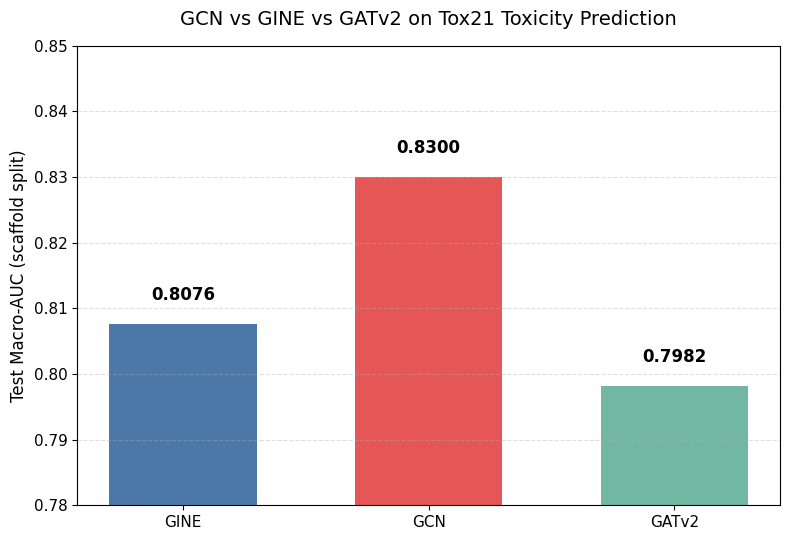

In [22]:
# ────────────────────────────────────────────────────────────────
#  Comparison: GCN vs GINE vs GATv2 on Tox21
# ────────────────────────────────────────────────────────────────

# Update with your actual numbers
gine_auc = 0.8076
gcn_auc  = 0.8300
gatv2_auc = test_auc_gatv2   # from the line above

plt.figure(figsize=(8, 5.5))

models = ['GINE', 'GCN', 'GATv2']
aucs   = [gine_auc, gcn_auc, gatv2_auc]
colors = ['#4c78a8', '#e45756', '#72b7a1']

bars = plt.bar(models, aucs, color=colors, width=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.003,
             f'{height:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel('Test Macro-AUC (scaffold split)', fontsize=12)
plt.title('GCN vs GINE vs GATv2 on Tox21 Toxicity Prediction', fontsize=14, pad=15)
plt.ylim(0.78, 0.85)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig("three_model_comparison_tox21.png", dpi=200, bbox_inches='tight')
plt.show()

Key observation :
Among the three models trained with identical hyperparameters and scaffold splitting, the plain GCN achieved the highest test macro-AUC of 0.8300, followed by GINE (0.8076) and GATv2 (0.7982). This suggests that, on this particular Tox21 scaffold fold, simpler neighborhood aggregation (GCN) generalized slightly better than attention-based (GATv2) or edge-aware (GINE) mechanisms.

In [6]:
# ────────────────────────────────────────────────────────────────
# Cell: Reload + Prepare All Models for Plotting (Publication Section)
# Purpose: Re-create environment + load best saved models
#          → uses the REAL scaffold test set (784 molecules)
# ────────────────────────────────────────────────────────────────

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GINEConv, GCNConv, GATv2Conv,
    BatchNorm, global_mean_pool, global_add_pool
)
from torch.nn import Sequential, Linear, ReLU
from sklearn.metrics import roc_auc_score, roc_curve
import seaborn as sns
import pandas as pd

# ─── Device ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ─── Reload Tox21 dataset ──────────────────────────────────────────────────
tox21 = MoleculeNet(root='./data/MoleculeNet', name='Tox21')
print(f"Loaded Tox21: {len(tox21)} molecules | Node feats: {tox21.num_node_features}")

# ─── REAL scaffold-based test indices (from your split) ─────────────────────
test_idx = [
    7390, 7724, 7517, 7239, 7009, 7564, 7715, 7155, 7464, 7664, 7704, 7212, 7650, 7234, 7131,
    7719, 7651, 7638, 7160, 6992, 7802, 7680, 7421, 7072, 7224, 7403, 7735, 7728, 7425, 7566,
    7022, 7785, 7657, 6977, 7805, 7358, 7364, 7409, 7043, 7456, 7119, 7665, 7709, 7491, 7536,
    7382, 7683, 7622, 7303, 7585, 7354, 7767, 7060, 7400, 7067, 7092, 7283, 7353, 7351, 7106,
    7783, 7598, 7447, 7618, 7089, 7424, 7420, 7328, 7180, 7095, 7329, 7404, 7367, 7362, 7376,
    6981, 7169, 7220, 7134, 7186, 7626, 7439, 7392, 7015, 7753, 7818, 7429, 7360, 7327, 7534,
    7305, 7356, 7734, 7484, 7824, 7285, 7227, 7544, 7116, 7074, 7068, 7267, 7282, 7694, 7815,
    7133, 7605, 7422, 7395, 7535, 7440, 7243, 7574, 7648, 7633, 7123, 7081, 7020, 7706, 7315,
    7363, 7049, 6976, 7301, 7414, 7776, 7206, 7668, 7537, 7798, 7223, 7554, 7810, 7510, 7503,
    7592, 6978, 7515, 7671, 7216, 7151, 7034, 7570, 7240, 7583, 6958, 7334, 7014, 7822, 7426,
    7737, 7549, 7071, 7307, 7232, 7702, 7344, 7402, 7349, 7126, 7039, 7601, 7219, 7085, 7365,
    7685, 7791, 7352, 7221, 7654, 7542, 7018, 7069, 7716, 7558, 7458, 7514, 7520, 7306, 7775,
    7643, 7548, 6973, 7452, 7438, 7325, 7713, 7428, 6953, 7708, 7129, 7792, 7168, 7725, 7611,
    7279, 7073, 7361, 7550, 7641, 7727, 7686, 7568, 7620, 7029, 6982, 6960, 7707, 7731, 7031,
    7498, 7581, 7705, 7080, 7369, 7463, 7782, 7711, 7044, 7467, 7357, 7684, 7260, 7266, 7506,
    7445, 7640, 7575, 7639, 7184, 7760, 7700, 7339, 7165, 6980, 7096, 7621, 7532, 7508, 7678,
    7181, 7124, 7545, 6985, 7759, 7726, 7569, 7636, 7698, 7738, 7284, 7502, 7275, 6989, 7318,
    7346, 6969, 7670, 7082, 7323, 7755, 7278, 7615, 7647, 7476, 7140, 7516, 7167, 7189, 7013,
    7645, 7251, 6993, 7481, 7448, 7819, 6983, 7086, 7415, 7012, 7451, 7397, 7699, 7316, 7063,
    7762, 7669, 7330, 7146, 7383, 7742, 7033, 7408, 7427, 7795, 7021, 7030, 7336, 7777, 7637,
    7157, 7794, 7479, 7246, 7721, 7748, 7687, 7019, 7461, 7158, 7104, 6998, 7152, 7595, 7384,
    7781, 7804, 7744, 6987, 7233, 7319, 7051, 6956, 7162, 7281, 7286, 7077, 7264, 7787, 7616,
    7295, 7533, 7195, 7076, 7526, 7355, 7493, 7296, 7673, 7052, 7141, 7310, 7387, 7265, 7017,
    7717, 7209, 7190, 7655, 7513, 7105, 7659, 7443, 7492, 7814, 7263, 7166, 7511, 7205, 6991,
    7079, 7625, 7054, 7261, 7538, 7231, 7597, 7573, 7293, 7154, 7056, 7556, 7417, 7553, 7483,
    7797, 7743, 7494, 7419, 7749, 7226, 7761, 7004, 7454, 7430, 6995, 7396, 7587, 7512, 7472,
    7298, 7037, 7677, 7200, 7107, 7703, 7120, 7557, 7600, 7674, 6964, 7541, 7613, 7161, 7385,
    7525, 7098, 7237, 7784, 7714, 7125, 7115, 7820, 7145, 7559, 7130, 7475, 7374, 7337, 7139,
    7159, 7187, 7196, 7023, 7202, 7114, 7371, 7547, 7287, 6970, 7827, 7097, 7210, 7398, 7692,
    7446, 7596, 7623, 7198, 7274, 7751, 7331, 7435, 7619, 7093, 7102, 7723, 7241, 7290, 7418,
    7653, 7128, 7050, 7182, 7584, 7528, 7183, 7373, 7122, 7394, 7628, 7289, 7399, 7720, 7236,
    7529, 7572, 7746, 7693, 7118, 7722, 7249, 7257, 7509, 7213, 7610, 7750, 7312, 7228, 7811,
    6994, 7242, 7561, 7808, 7455, 7048, 7560, 7058, 7642, 7471, 7178, 7127, 6963, 7199, 7786,
    7649, 7277, 7193, 7658, 7499, 7215, 7313, 6972, 7646, 7253, 7208, 7779, 7348, 7789, 7627,
    7431, 7718, 7117, 7214, 7149, 7632, 7324, 7308, 7332, 7061, 7147, 7774, 7617, 7609, 7546,
    7309, 7449, 7799, 7442, 7258, 7825, 6954, 7505, 7211, 7271, 7238, 7501, 7482, 7543, 7377,
    7235, 7407, 7070, 7629, 7504, 7586, 7580, 7478, 7450, 7288, 7010, 7222, 7624, 7565, 7032,
    7368, 7268, 7752, 7299, 7225, 7304, 7675, 7135, 7690, 7016, 7380, 7388, 7083, 7614, 7008,
    7113, 7294, 7697, 7660, 7203, 7793, 7676, 7780, 7423, 7055, 7790, 7099, 7630, 7342, 7593,
    7477, 7142, 7192, 7197, 7462, 7530, 7389, 7201, 7391, 7807, 7681, 7773, 7091, 7042, 7588,
    7111, 7758, 6975, 7563, 7480, 7302, 7470, 7138, 7341, 7809, 7110, 7040, 6957, 7252, 7001,
    7552, 7608, 7372, 7571, 7591, 7806, 7256, 7322, 7311, 7094, 7582, 7176, 7606, 7297, 7466,
    7631, 7005, 6979, 7002, 7497, 7262, 7321, 6967, 7661, 7340, 7602, 7739, 7163, 7255, 7539,
    7524, 7489, 7765, 7826, 7245, 7691, 7459, 7047, 7656, 7057, 7730, 7191, 7007, 7366, 7185,
    7562, 7444, 7488, 6974, 7109, 7604, 7026, 7112, 7679, 7453, 7248, 7486, 7217, 7405, 7434,
    7153, 7473, 7045, 7150, 7359, 7496, 7401, 7756, 7170, 7148, 7025, 7280, 7177, 6986, 7757,
    7816, 7441, 7823, 7174, 7244, 7024, 7136, 6962, 7335, 7490, 7229, 7179, 7247, 7689, 7078,
    7412, 7607, 7666, 7634, 7254, 7487, 7555, 7103, 7053, 7250, 7518, 7682, 7188, 7144, 7732,
    7171, 7754, 7218, 7087, 7710, 7230, 7143, 7433, 7259, 7495, 7644, 7075, 7410, 7500, 7437,
    7381, 7672, 7485, 7011, 7830, 7745, 7172, 7788, 7066, 7662, 7156, 6961, 7589, 7747, 7173,
    7046, 6955, 7778, 7204, 7733, 7386, 7038, 7821, 7320, 7594, 7088, 7090, 7393, 7800, 7338,
    6984, 7006, 7121, 7599, 7065, 7314, 7701, 6968, 7763, 7801, 7084, 7350, 7817, 7567, 7712,
    7519, 7729, 7347, 7041
]

print(f"Using real scaffold test set → {len(test_idx)} molecules")
print(f"Min index: {min(test_idx)}, Max index: {max(test_idx)} (valid range: 0–{len(tox21)-1})")

# ─── Create REAL test loader ───────────────────────────────────────────────
test_data_list = [tox21[i] for i in test_idx]
tox_test_loader = DataLoader(test_data_list, batch_size=64, shuffle=False)
print(f"Test loader ready: {len(test_data_list)} graphs")

# ─── Model definitions ─────────────────────────────────────────────────────

class BestTox21GNN(torch.nn.Module):  # GINE
    def __init__(self, in_channels, edge_dim, hidden=256, num_tasks=12, dropout=0.25):
        super().__init__()
        def gin_mlp(in_dim, out_dim):
            return Sequential(
                Linear(in_dim, out_dim),
                ReLU(),
                Linear(out_dim, out_dim)
            )
        self.conv1 = GINEConv(gin_mlp(in_channels, hidden), edge_dim=edge_dim)
        self.bn1 = BatchNorm(hidden)
        self.conv2 = GINEConv(gin_mlp(hidden, hidden), edge_dim=edge_dim)
        self.bn2 = BatchNorm(hidden)
        self.conv3 = GINEConv(gin_mlp(hidden, hidden), edge_dim=edge_dim)
        self.bn3 = BatchNorm(hidden)
        self.conv4 = GINEConv(gin_mlp(hidden, hidden), edge_dim=edge_dim)
        self.bn4 = BatchNorm(hidden)
        self.lin1 = Linear(hidden * 2, hidden)
        self.lin2 = Linear(hidden, num_tasks)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x.float().clamp(-10,10),
            data.edge_index,
            data.edge_attr.float() if hasattr(data, 'edge_attr') and data.edge_attr is not None else None,
            data.batch
        )
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_attr)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_attr)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn3(self.conv3(x, edge_index, edge_attr)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn4(self.conv4(x, edge_index, edge_attr)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x_mean = global_mean_pool(x, batch)
        x_sum  = global_add_pool(x, batch)
        x_pool = torch.cat([x_mean, x_sum], dim=-1)
        x = F.relu(self.lin1(x_pool))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin2(x).clamp(-10, 10)


class GCNTox21(torch.nn.Module):
    def __init__(self, in_channels, hidden=256, num_tasks=12, dropout=0.25):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.bn1   = BatchNorm(hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.bn2   = BatchNorm(hidden)
        self.conv3 = GCNConv(hidden, hidden)
        self.bn3   = BatchNorm(hidden)
        self.conv4 = GCNConv(hidden, hidden)
        self.bn4   = BatchNorm(hidden)
        self.lin1  = Linear(hidden * 2, hidden)
        self.lin2  = Linear(hidden, num_tasks)
        self.dropout = dropout

    def forward(self, data):
        x = data.x.float().clamp(-10, 10)
        edge_index = data.edge_index
        batch = data.batch
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn4(self.conv4(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x_mean = global_mean_pool(x, batch)
        x_sum  = global_add_pool(x, batch)
        x_pool = torch.cat([x_mean, x_sum], dim=-1)
        x = F.relu(self.lin1(x_pool))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin2(x).clamp(-10, 10)


class GATv2Tox21(torch.nn.Module):
    def __init__(self, in_channels, hidden=256, num_tasks=12, dropout=0.3, heads=4):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden // heads, heads=heads, concat=True, dropout=dropout)
        self.bn1   = BatchNorm(hidden)
        self.conv2 = GATv2Conv(hidden, hidden // heads, heads=heads, concat=True, dropout=dropout)
        self.bn2   = BatchNorm(hidden)
        self.conv3 = GATv2Conv(hidden, hidden // heads, heads=heads, concat=True, dropout=dropout)
        self.bn3   = BatchNorm(hidden)
        self.conv4 = GATv2Conv(hidden, hidden // heads, heads=heads, concat=True, dropout=dropout)
        self.bn4   = BatchNorm(hidden)
        self.lin1  = Linear(hidden * 2, hidden)
        self.lin2  = Linear(hidden, num_tasks)
        self.dropout = dropout

    def forward(self, data):
        x = data.x.float().clamp(-10, 10)
        edge_index = data.edge_index
        batch = data.batch
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.bn3(self.conv3(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.bn4(self.conv4(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x_mean = global_mean_pool(x, batch)
        x_sum  = global_add_pool(x, batch)
        x_pool = torch.cat([x_mean, x_sum], dim=-1)
        x = F.elu(self.lin1(x_pool))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin2(x).clamp(-10, 10)


# ─── Instantiate models ────────────────────────────────────────────────────
model_gine = BestTox21GNN(9, 3, hidden=256, num_tasks=12, dropout=0.25).to(device)
model_gcn  = GCNTox21(9, hidden=256, num_tasks=12, dropout=0.25).to(device)
model_gat  = GATv2Tox21(9, hidden=256, num_tasks=12, dropout=0.3, heads=4).to(device)


# ─── Load best checkpoints ─────────────────────────────────────────────────
print("\nLoading best models from checkpoint files...")
try:
    model_gine.load_state_dict(torch.load("best_model_scaffold.pt", map_location=device))
    model_gcn.load_state_dict(torch.load("best_gcn_tox21_scaffold.pt", map_location=device))
    model_gat.load_state_dict(torch.load("best_gatv2_tox21_scaffold.pt", map_location=device))
    print("✓ Successfully loaded GINE, GCN, and GATv2 checkpoints")
except Exception as e:
    print("⚠️  One or more checkpoints could not be loaded:")
    print(e)
    print("Check that the .pt files exist in the current directory.")

# ─── Set evaluation mode ───────────────────────────────────────────────────
model_gine.eval()
model_gcn.eval()
model_gat.eval()

print(f"\nModels ready on {device}")
print(f"GINE parameters: {sum(p.numel() for p in model_gine.parameters()):,}")
print(f" GCN parameters: {sum(p.numel() for p in model_gcn.parameters()):,}")
print(f"GATv2 parameters: {sum(p.numel() for p in model_gat.parameters()):,}")
print("Ready for evaluation and plotting cells.")

Loaded Tox21: 7831 molecules | Node feats: 9
Using real scaffold test set → 784 molecules
Min index: 6953, Max index: 7830 (valid range: 0–7830)
Test loader ready: 784 graphs

Loading best models from checkpoint files...
✓ Successfully loaded GINE, GCN, and GATv2 checkpoints

Models ready on cuda
GINE parameters: 602,672
 GCN parameters: 336,396
GATv2 parameters: 538,380
Ready for evaluation and plotting cells.


In [7]:
# Cell 1 - Define shared constants and helper function

task_names = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
    'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]

@torch.no_grad()
def evaluate_model(model, loader, model_name="Model"):
    model.eval()
    all_logits = []
    all_labels = []

    for batch in loader:
        batch = batch.to(device)
        out = model(batch)
        all_logits.append(out.cpu())
        all_labels.append(batch.y.cpu())

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()

    aucs = []
    n_valid_tasks = 0

    print(f"\n{model_name} - Test set evaluation")
    print("-"*65)

    for i, task in enumerate(task_names):
        mask = (~np.isnan(labels[:,i])) & (labels[:,i] != -1)
        if mask.sum() < 10:
            aucs.append(np.nan)
            print(f"{task:12} : too few valid samples")
            continue

        auc = roc_auc_score(labels[mask,i], logits[mask,i])
        aucs.append(auc)
        n_valid_tasks += 1
        print(f"{task:12} : {auc:.4f}")

    macro_auc = np.nanmean(aucs)
    print(f"\nMacro-averaged AUC : {macro_auc:.4f}   ({n_valid_tasks}/12 tasks)")
    print("-"*65 + "\n")

    return aucs, macro_auc

In [8]:
# Cell 2 - Evaluate each model separately

print("Evaluating GINE model...")
gine_aucs, gine_macro = evaluate_model(model_gine, tox_test_loader, "GINE")

print("\nEvaluating GCN model...")
gcn_aucs,  gcn_macro  = evaluate_model(model_gcn,  tox_test_loader, "GCN")

print("\nEvaluating GATv2 model...")
gat_aucs,  gat_macro  = evaluate_model(model_gat,  tox_test_loader, "GATv2")

Evaluating GINE model...

GINE - Test set evaluation
-----------------------------------------------------------------
NR-AR        : 0.8317
NR-AR-LBD    : 0.8777
NR-AhR       : 0.8758
NR-Aromatase : 0.8347
NR-ER        : 0.7258
NR-ER-LBD    : 0.7886
NR-PPAR-gamma : 0.7637
SR-ARE       : 0.7655
SR-ATAD5     : 0.8044
SR-HSE       : 0.7548
SR-MMP       : 0.8576
SR-p53       : 0.8108

Macro-averaged AUC : 0.8076   (12/12 tasks)
-----------------------------------------------------------------


Evaluating GCN model...

GCN - Test set evaluation
-----------------------------------------------------------------
NR-AR        : 0.8889
NR-AR-LBD    : 0.8707
NR-AhR       : 0.8902
NR-Aromatase : 0.8460
NR-ER        : 0.7379
NR-ER-LBD    : 0.8160
NR-PPAR-gamma : 0.7855
SR-ARE       : 0.8039
SR-ATAD5     : 0.8303
SR-HSE       : 0.7991
SR-MMP       : 0.8745
SR-p53       : 0.8173

Macro-averaged AUC : 0.8300   (12/12 tasks)
-----------------------------------------------------------------


Evaluati

In [9]:
# Cell 3 - Create comparison DataFrame + print nice table

import pandas as pd

results_df = pd.DataFrame({
    'Task'     : task_names + ['Macro-AUC'],
    'GINE'     : gine_aucs + [gine_macro],
    'GCN'      : gcn_aucs  + [gcn_macro],
    'GATv2'    : gat_aucs  + [gat_macro]
})

# round for nicer display
results_df.iloc[:,1:] = results_df.iloc[:,1:].round(4)

print("\nFinal comparison table (scaffold test set)")
print(results_df.to_string(index=False))

# Optional: save to file
results_df.to_csv("tox21_gnn_comparison_scaffold.csv", index=False)


Final comparison table (scaffold test set)
         Task   GINE    GCN  GATv2
        NR-AR 0.8317 0.8889 0.8013
    NR-AR-LBD 0.8777 0.8707 0.8235
       NR-AhR 0.8758 0.8902 0.8750
 NR-Aromatase 0.8347 0.8460 0.8372
        NR-ER 0.7258 0.7379 0.7239
    NR-ER-LBD 0.7886 0.8160 0.7712
NR-PPAR-gamma 0.7637 0.7855 0.7485
       SR-ARE 0.7655 0.8039 0.7689
     SR-ATAD5 0.8044 0.8303 0.8018
       SR-HSE 0.7548 0.7991 0.7949
       SR-MMP 0.8576 0.8745 0.8519
       SR-p53 0.8108 0.8173 0.7799
    Macro-AUC 0.8076 0.8300 0.7982


Computing Morgan fingerprints for all molecules...


[23:09:14] WARNING: not removing hydrogen atom without neighbors


 → 7831 valid molecules loaded
Running t-SNE on 7831 molecules (may take 10–60 seconds)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 7831 samples in 0.015s...
[t-SNE] Computed neighbors for 7831 samples in 6.244s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7831
[t-SNE] Computed conditional probabilities for sample 2000 / 7831
[t-SNE] Computed conditional probabilities for sample 3000 / 7831
[t-SNE] Computed conditional probabilities for sample 4000 / 7831
[t-SNE] Computed conditional probabilities for sample 5000 / 7831
[t-SNE] Computed conditional probabilities for sample 6000 / 7831
[t-SNE] Computed conditional probabilities for sample 7000 / 7831
[t-SNE] Computed conditional probabilities for sample 7831 / 7831
[t-SNE] Mean sigma: 1.543472
[t-SNE] KL divergence after 250 iterations with early exaggeration: 92.055649
[t-SNE] KL divergence after 1000 iterations: 2.125329


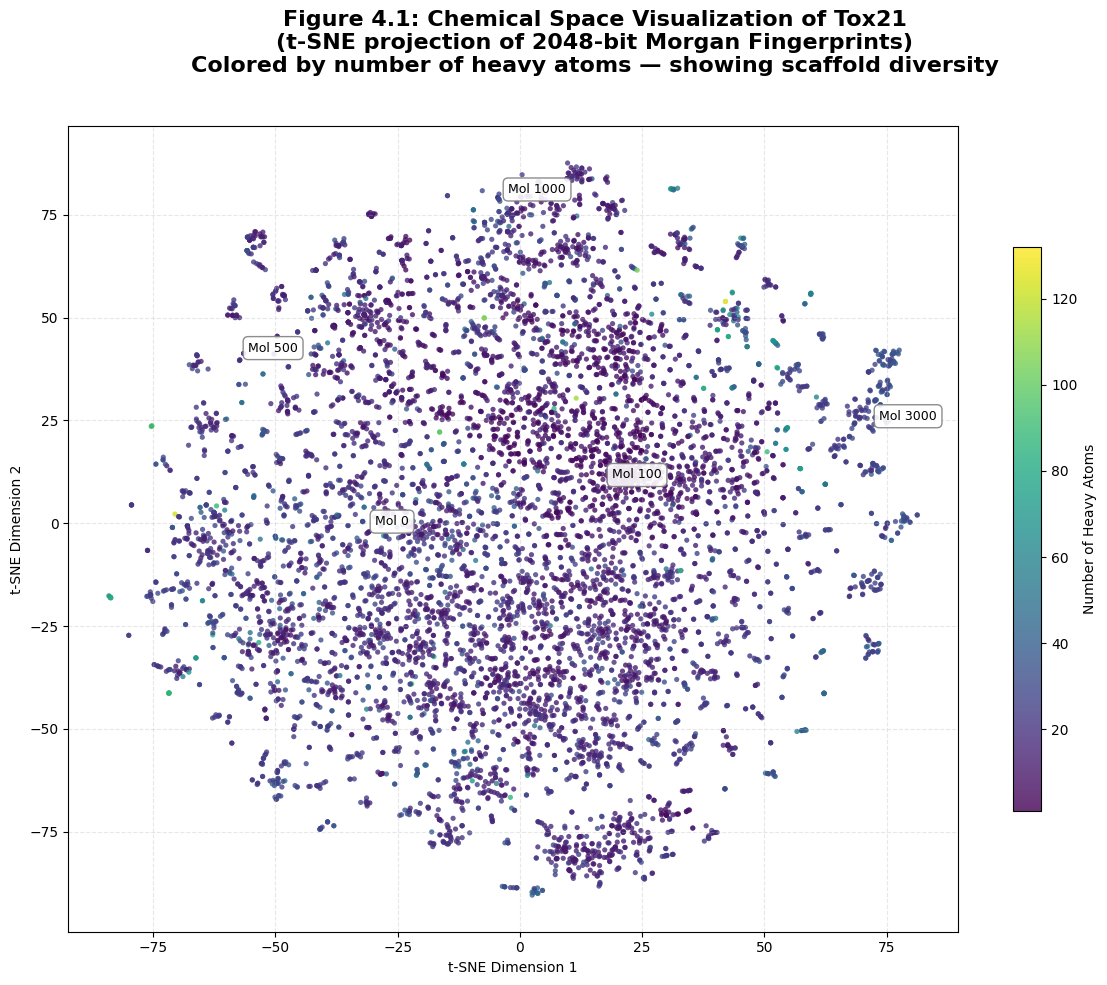

✅ Figure saved as 'Figure_4.1_Tox21_Chemical_Space_tSNE_light.png' (350 DPI)


In [20]:
# ────────────────────────────────────────────────────────────────
# Figure 4.1 — Chemical Space Visualization of Tox21
# (t-SNE of Morgan Fingerprints showing scaffold diversity)
# ────────────────────────────────────────────────────────────────

from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# ─── Prepare molecules and fingerprints ───────────────────────────────
print("Computing Morgan fingerprints for all molecules...")

mols = []
heavy_atoms = []

# Assuming 'tox21' is your list/df of compounds with .smiles attribute
# Example: tox21 = pd.read_csv("tox21.csv")  # ← load your data here if needed
for data in tox21:
    mol = Chem.MolFromSmiles(data.smiles)
    if mol is None:
        continue
    mols.append(mol)
    heavy_atoms.append(mol.GetNumHeavyAtoms())

print(f" → {len(mols)} valid molecules loaded")

# Convert to 2048-bit Morgan fingerprints (ECFP4-like)
fps = [
    AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    for mol in mols
]

# Convert RDKit fingerprints to numpy array
fps_array = np.zeros((len(fps), 2048), dtype=np.float32)
for i, fp in enumerate(fps):
    AllChem.DataStructs.ConvertToNumpyArray(fp, fps_array[i])

# ─── t-SNE dimensionality reduction ───────────────────────────────────
print(f"Running t-SNE on {len(fps_array)} molecules (may take 10–60 seconds)...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    early_exaggeration=12.0,
    learning_rate='auto',
    max_iter=1000,
    n_iter_without_progress=300,
    min_grad_norm=1e-7,
    random_state=42,
    init='pca',
    n_jobs=-1,
    verbose=1
)

X_tsne = tsne.fit_transform(fps_array)

# ─── Plot (publication-ready, light background) ───────────────────────
fig = plt.figure(figsize=(12, 10))

# Main title above the plot area
fig.suptitle(
    'Figure 4.1: Chemical Space Visualization of Tox21\n'
    '(t-SNE projection of 2048-bit Morgan Fingerprints)\n'
    'Colored by number of heavy atoms — showing scaffold diversity',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

scatter = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=heavy_atoms,
    cmap='viridis',
    s=14,
    alpha=0.80,
    edgecolors='none',
    linewidth=0
)

plt.colorbar(scatter, label='Number of Heavy Atoms', shrink=0.7)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

plt.grid(True, linestyle='--', alpha=0.3)

# Optional: annotate a few example molecules
example_indices = [0, 100, 500, 1000, 3000]  # ← change as desired
for idx in example_indices:
    if idx < len(X_tsne):
        plt.annotate(
            f"Mol {idx}",
            (X_tsne[idx, 0], X_tsne[idx, 1]),
            xytext=(6, 6),
            textcoords='offset points',
            fontsize=9,
            color='black',
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
        )

plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle

plt.savefig(
    "Figure_4.1_Tox21_Chemical_Space_tSNE_light.png",
    dpi=350,
    bbox_inches='tight'
)
plt.show()

print("✅ Figure saved as 'Figure_4.1_Tox21_Chemical_Space_tSNE_light.png' (350 DPI)")

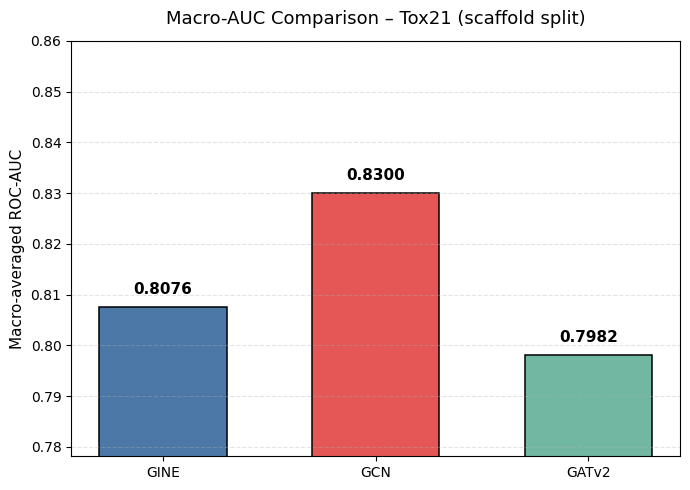

In [7]:
# Cell 4 - Bar plot - Macro AUC comparison

import matplotlib.pyplot as plt

models = ['GINE', 'GCN', 'GATv2']
macros = [gine_macro, gcn_macro, gat_macro]
colors = ['#4c78a8', '#e45756', '#72b7a1']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, macros, color=colors, width=0.6, edgecolor='black', linewidth=1.1)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y+0.002, f'{y:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Macro-AUC Comparison – Tox21 (scaffold split)', fontsize=13, pad=12)
plt.ylabel('Macro-averaged ROC-AUC', fontsize=11)
plt.ylim(min(macros)-0.02, max(macros)+0.03)
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig("macro_auc_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

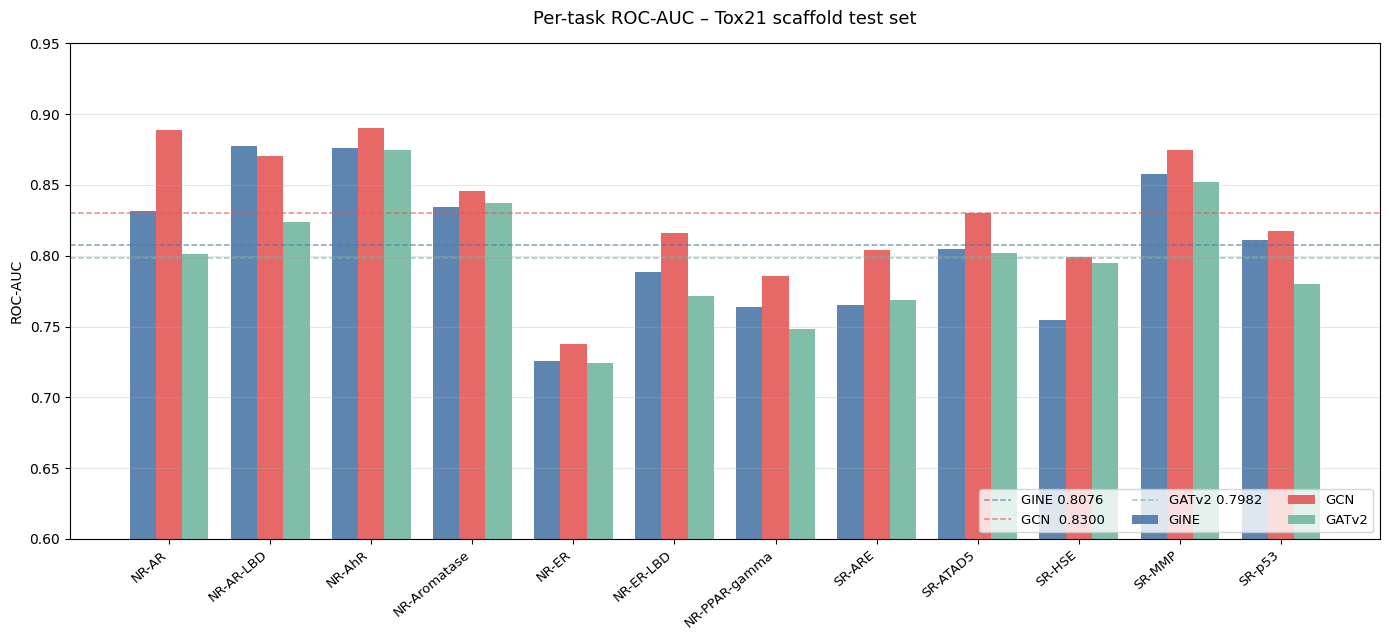

In [8]:
# Cell 5 - Grouped bar plot – per-task comparison

import numpy as np

x = np.arange(len(task_names))
width = 0.26

plt.figure(figsize=(14, 6.5))

plt.bar(x - width,   gine_aucs, width, label='GINE',   color='#4c78a8', alpha=0.9)
plt.bar(x,           gcn_aucs,  width, label='GCN',    color='#e45756', alpha=0.9)
plt.bar(x + width,   gat_aucs,  width, label='GATv2',  color='#72b7a1', alpha=0.9)

plt.axhline(gine_macro, color='#4c78a8', ls='--', lw=1.1, alpha=0.7, label=f'GINE {gine_macro:.4f}')
plt.axhline(gcn_macro,  color='#e45756',  ls='--', lw=1.1, alpha=0.7, label=f'GCN  {gcn_macro:.4f}')
plt.axhline(gat_macro,  color='#72b7a1',  ls='--', lw=1.1, alpha=0.7, label=f'GATv2 {gat_macro:.4f}')

plt.xticks(x, task_names, rotation=40, ha='right', fontsize=9.5)
plt.ylabel('ROC-AUC')
plt.title('Per-task ROC-AUC – Tox21 scaffold test set', pad=14, fontsize=13)
plt.legend(loc='lower right', ncol=3, fontsize=9.5)
plt.ylim(0.60, 0.95)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("per_task_grouped_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

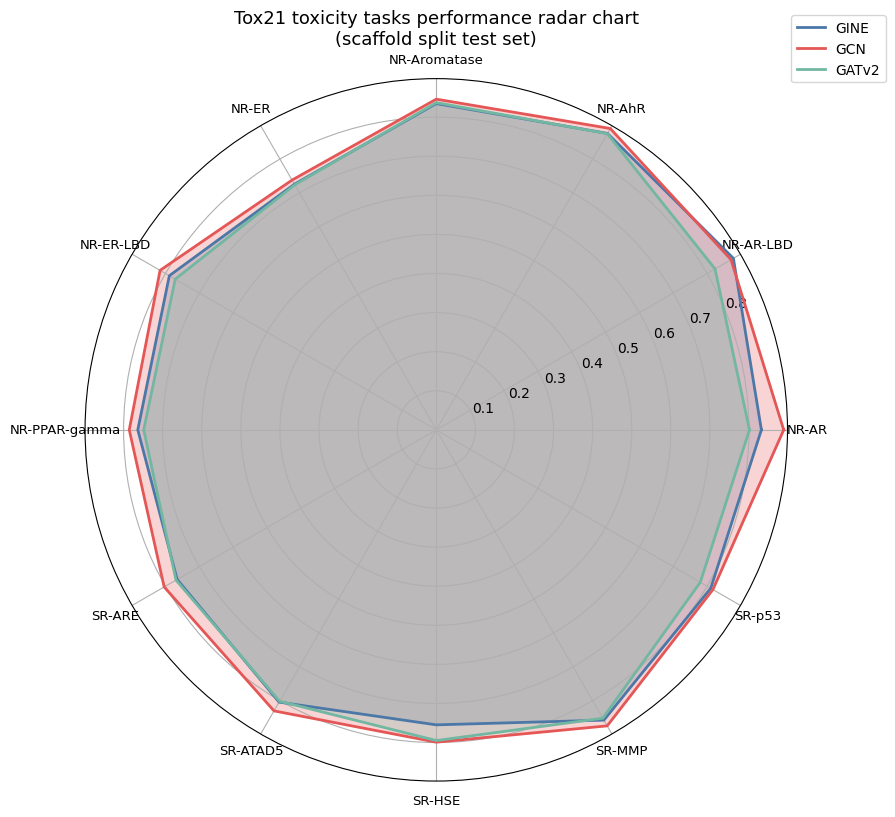

In [9]:
# Cell 6 - Radar (spider) chart

import math

angles = np.linspace(0, 2*np.pi, len(task_names), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))

for name, values, color, alpha in [
    ('GINE',  gine_aucs, '#4c78a8', 0.25),
    ('GCN',   gcn_aucs,  '#e45756', 0.25),
    ('GATv2', gat_aucs,  '#72b7a1', 0.25)
]:
    vals = np.nan_to_num(values, nan=0.5)   # handle possible NaNs
    vals = np.append(vals, vals[0])
    ax.plot(angles, vals, linewidth=2, label=name, color=color)
    ax.fill(angles, vals, color=color, alpha=alpha)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(task_names, fontsize=9.5)
ax.set_title("Tox21 toxicity tasks performance radar chart\n(scaffold split test set)", fontsize=13, pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.1))
plt.tight_layout()
plt.savefig("radar_comparison_tox21.png", dpi=300, bbox_inches='tight')
plt.show()

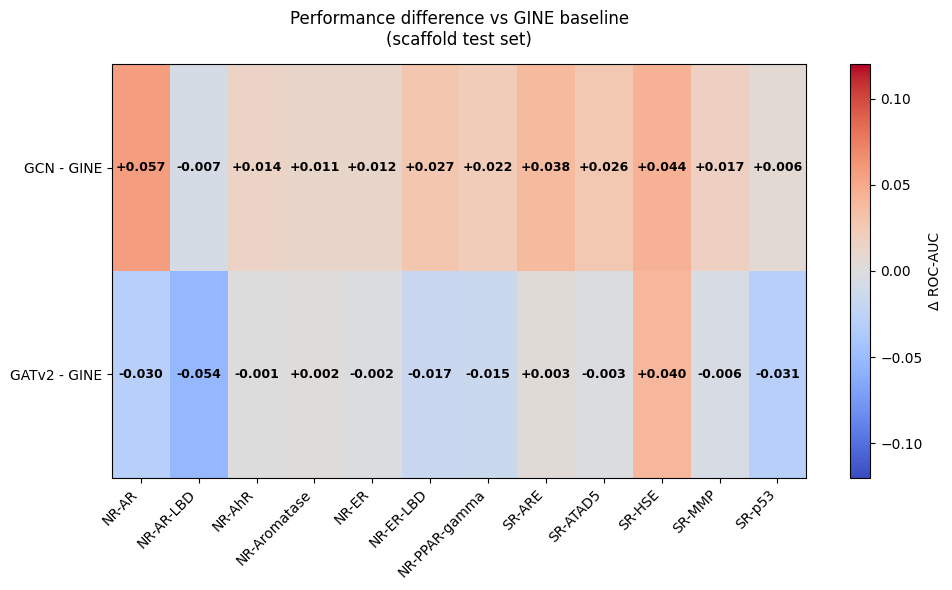

In [10]:
# Cell 7 - Heatmap of differences (GCN - GINE) and (GATv2 - GINE)

diff_gcn_gine  = np.array(gcn_aucs)  - np.array(gine_aucs)
diff_gat_gine  = np.array(gat_aucs)  - np.array(gine_aucs)

plt.figure(figsize=(10, 6))

data = np.vstack([diff_gcn_gine, diff_gat_gine])
cax = plt.imshow(data, cmap='coolwarm', aspect='auto', vmin=-0.12, vmax=0.12)

plt.xticks(np.arange(len(task_names)), task_names, rotation=45, ha='right')
plt.yticks([0,1], ['GCN - GINE', 'GATv2 - GINE'])
plt.colorbar(cax, label='Δ ROC-AUC')

for i in range(2):
    for j in range(len(task_names)):
        val = data[i,j]
        if not np.isnan(val):
            plt.text(j, i, f"{val:+.3f}", ha='center', va='center',
                     color='white' if abs(val)>0.06 else 'black',
                     fontsize=9, fontweight='bold')

plt.title("Performance difference vs GINE baseline\n(scaffold test set)", pad=14)
plt.tight_layout()
plt.savefig("difference_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

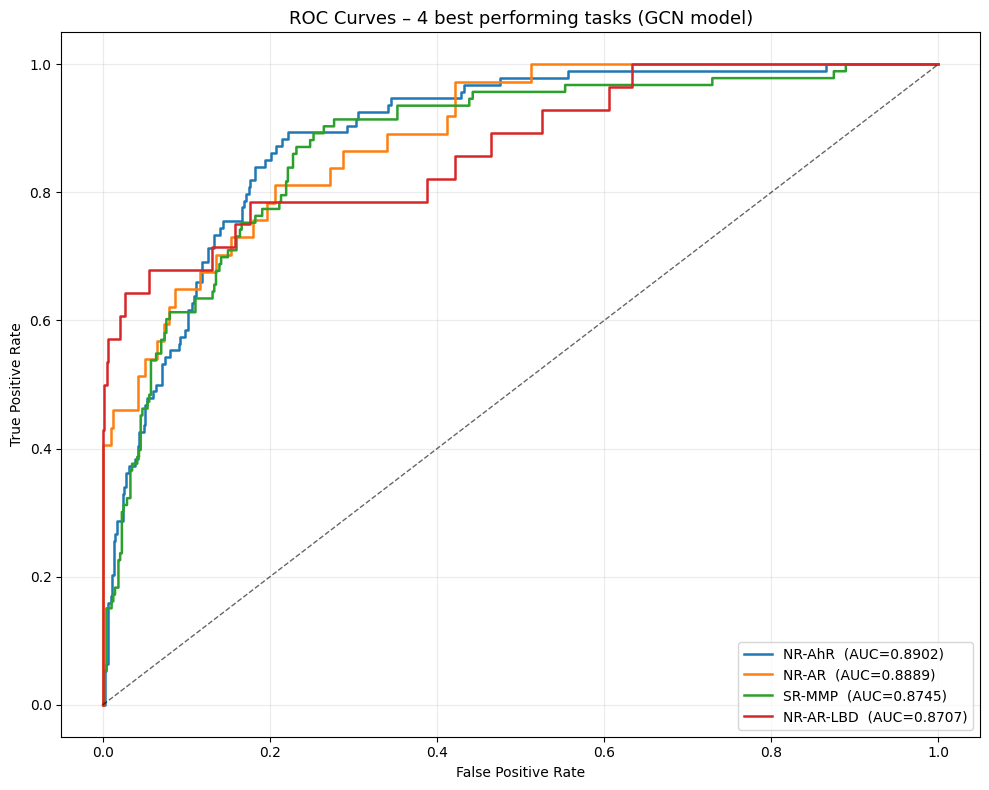

In [11]:
# Cell 8 - ROC curves - top 4 tasks of the best model (usually GCN)

# Collect logits & labels once more from the best model (GCN)
@torch.no_grad()
def get_logits_labels(model, loader):
    model.eval()
    logits_list, labels_list = [], []
    for batch in loader:
        batch = batch.to(device)
        out = model(batch)
        logits_list.append(out.cpu())
        labels_list.append(batch.y.cpu())
    return torch.cat(logits_list).numpy(), torch.cat(labels_list).numpy()

logits, labels = get_logits_labels(model_gcn, tox_test_loader)

# Select 4 best tasks according to GCN
top4_idx = np.argsort(gcn_aucs)[-4:][::-1]

plt.figure(figsize=(10, 8))

for idx in top4_idx:
    mask = (~np.isnan(labels[:,idx])) & (labels[:,idx] != -1)
    if mask.sum() < 20: continue
    fpr, tpr, _ = roc_curve(labels[mask,idx], logits[mask,idx])
    plt.plot(fpr, tpr, lw=1.8, label=f"{task_names[idx]}  (AUC={gcn_aucs[idx]:.4f})")

plt.plot([0,1], [0,1], 'k--', lw=1, alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – 4 best performing tasks (GCN model)', fontsize=13)
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("roc_top4_gcn.png", dpi=300, bbox_inches='tight')
plt.show()

Computing per-task test AUCs for all models...
GCN  Macro-AUC: 0.8300
GINE Macro-AUC: 0.8076
GATv2 Macro-AUC: 0.7982

Generating combined ROC plot for top 4 tasks across all models...


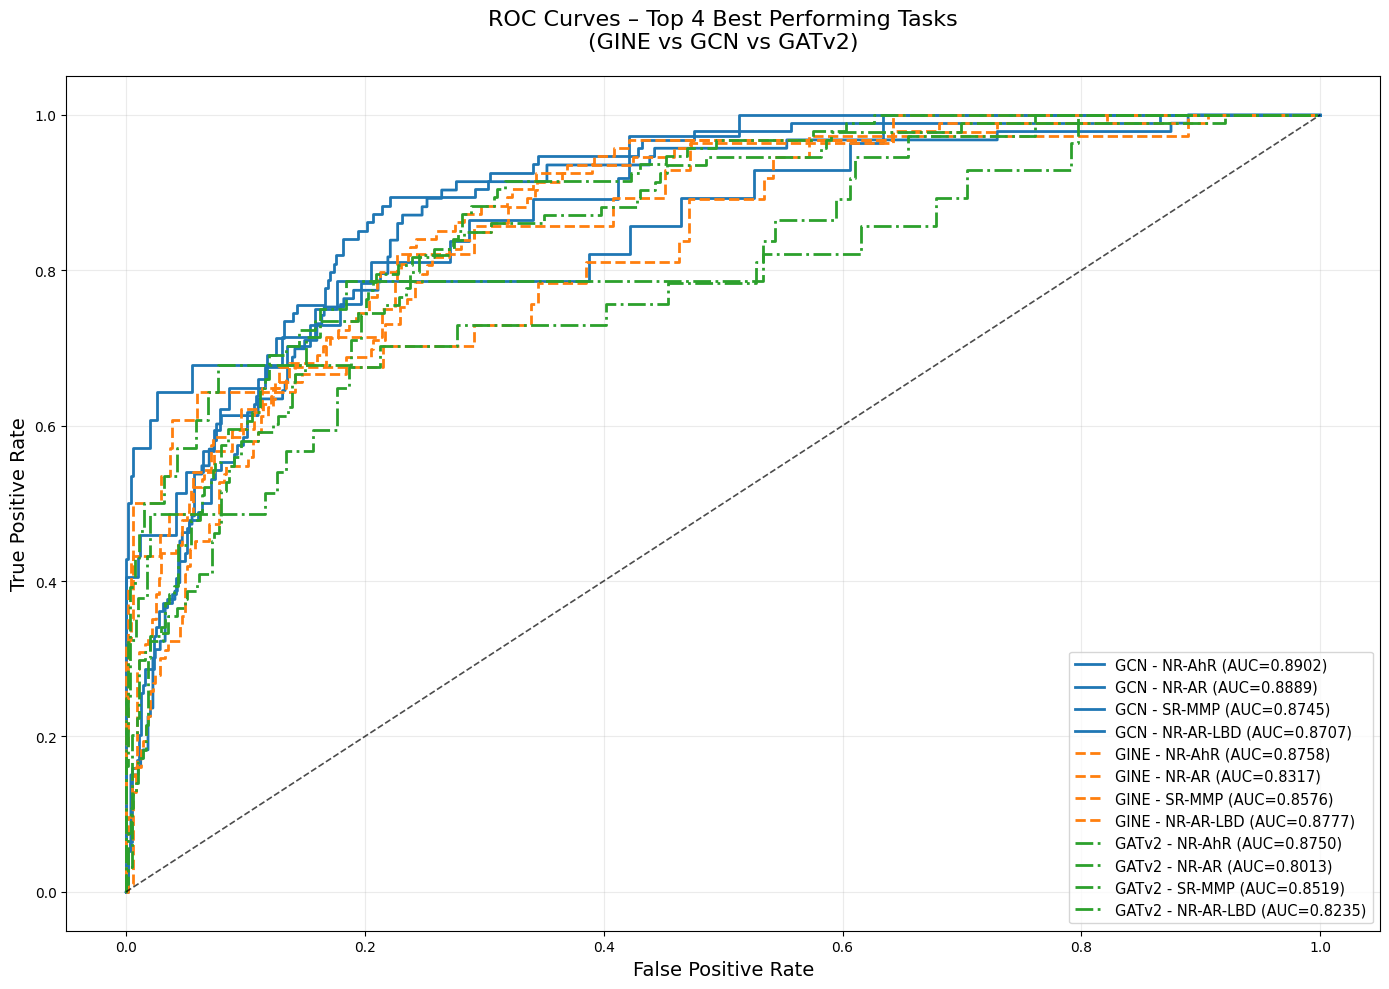

✓ Combined ROC plot saved as: roc_top4_combined_gine_gcn_gatv2.png


In [12]:
# ────────────────────────────────────────────────────────────────
# Cell: Combined ROC Curves - Top 4 Tasks for GINE, GCN & GATv2 (One Figure)
# ────────────────────────────────────────────────────────────────

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ====================== HELPER FUNCTION ======================
@torch.no_grad()
def get_logits_labels(model, loader, device):
    model.eval()
    logits_list, labels_list = [], []
    for batch in loader:
        batch = batch.to(device)
        out = model(batch)
        logits_list.append(out.cpu())
        labels_list.append(batch.y.cpu())
    return torch.cat(logits_list).numpy(), torch.cat(labels_list).numpy()


# ====================== COMPUTE PER-TASK AUCs ======================
print("Computing per-task test AUCs for all models...")

def compute_per_task_auc(model, loader, device):
    logits, labels = get_logits_labels(model, loader, device)
    aucs = []
    for i in range(labels.shape[1]):
        mask = (~np.isnan(labels[:, i])) & (labels[:, i] != -1)
        if mask.sum() < 20:
            aucs.append(0.5)
            continue
        try:
            auc = roc_auc_score(labels[mask, i], logits[mask, i])
            aucs.append(auc)
        except:
            aucs.append(0.5)
    return np.array(aucs)


gine_aucs = compute_per_task_auc(model_gine, tox_test_loader, device)
gcn_aucs  = compute_per_task_auc(model_gcn,  tox_test_loader, device)
gat_aucs  = compute_per_task_auc(model_gat,  tox_test_loader, device)

print(f"GCN  Macro-AUC: {gcn_aucs.mean():.4f}")
print(f"GINE Macro-AUC: {gine_aucs.mean():.4f}")
print(f"GATv2 Macro-AUC: {gat_aucs.mean():.4f}")


# ====================== COMBINED ROC PLOT (All 3 Models) ======================
print("\nGenerating combined ROC plot for top 4 tasks across all models...")

# Get top 4 tasks based on GCN (usually the best model)
top4_idx = np.argsort(gcn_aucs)[-4:][::-1]

plt.figure(figsize=(14, 10))

colors = {
    'GCN':  '#1f77b4',   # Blue
    'GINE': '#ff7f0e',   # Orange
    'GATv2':'#2ca02c'    # Green
}

line_styles = {'GCN': '-', 'GINE': '--', 'GATv2': '-.'}

models_data = [
    ('GCN',  model_gcn,  gcn_aucs,  colors['GCN']),
    ('GINE', model_gine, gine_aucs, colors['GINE']),
    ('GATv2',model_gat,  gat_aucs,  colors['GATv2'])
]

for model_name, model, auc_scores, color in models_data:
    logits, labels = get_logits_labels(model, tox_test_loader, device)
    
    for idx in top4_idx:
        mask = (~np.isnan(labels[:, idx])) & (labels[:, idx] != -1)
        if mask.sum() < 20:
            continue
            
        fpr, tpr, _ = roc_curve(labels[mask, idx], logits[mask, idx])
        auc = auc_scores[idx]
        
        label = f"{model_name} - {task_names[idx]} (AUC={auc:.4f})"
        
        plt.plot(fpr, tpr, lw=2.0, color=color, linestyle=line_styles[model_name],
                 label=label)

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.7)

plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curves – Top 4 Best Performing Tasks\n(GINE vs GCN vs GATv2)', 
          fontsize=16, pad=20)

plt.legend(loc='lower right', fontsize=10.5, frameon=True)
plt.grid(alpha=0.25)
plt.tight_layout()

# Save the combined figure
plt.savefig("roc_top4_combined_gine_gcn_gatv2.png", dpi=400, bbox_inches='tight')
plt.show()

print("✓ Combined ROC plot saved as: roc_top4_combined_gine_gcn_gatv2.png")

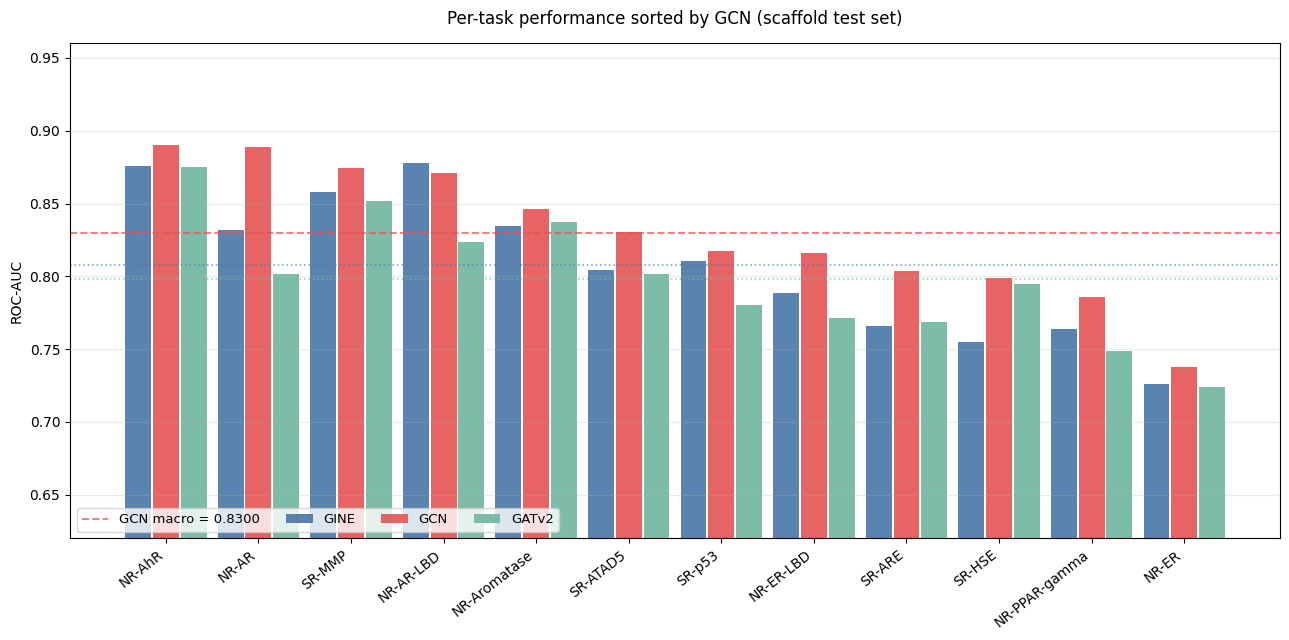

In [12]:
# Cell A1 – sorted bar plot (best → worst task) for each model + macro line

fig, ax = plt.subplots(figsize=(13, 6.5))

# sort by GCN performance (or change to another model)
sort_idx = np.argsort(gcn_aucs)[::-1]
sorted_tasks = [task_names[i] for i in sort_idx]

gine_sorted = [gine_aucs[i] for i in sort_idx]
gcn_sorted  = [gcn_aucs[i]  for i in sort_idx]
gat_sorted  = [gat_aucs[i]  for i in sort_idx]

x = np.arange(len(sorted_tasks))

ax.bar(x - 0.3, gine_sorted, 0.28, label='GINE',   color='#4c78a8', alpha=0.92)
ax.bar(x,       gcn_sorted,  0.28, label='GCN',    color='#e45756', alpha=0.92)
ax.bar(x + 0.3, gat_sorted,  0.28, label='GATv2',  color='#72b7a1', alpha=0.92)

ax.axhline(gcn_macro,  color='#e45756', ls='--', lw=1.4, alpha=0.75, label=f'GCN macro = {gcn_macro:.4f}')
ax.axhline(gine_macro, color='#4c78a8', ls=':',  lw=1.2, alpha=0.65)
ax.axhline(gat_macro,  color='#72b7a1', ls=':',  lw=1.2, alpha=0.65)

ax.set_xticks(x)
ax.set_xticklabels(sorted_tasks, rotation=38, ha='right', fontsize=9.8)
ax.set_ylabel('ROC-AUC')
ax.set_title('Per-task performance sorted by GCN (scaffold test set)', pad=14)
ax.legend(ncol=4, loc='lower left', fontsize=9.5)
ax.grid(axis='y', alpha=0.28)
ax.set_ylim(0.62, 0.96)

plt.tight_layout()
plt.savefig("per_task_sorted_by_gcn.png", dpi=320, bbox_inches='tight')
plt.show()

C:\Users\ghosh\AppData\Local\Temp\ipykernel_7252\4022183369.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='ROC-AUC', data=df_long, width=0.4, palette=['#4c78a8','#e45756','#72b7a1'])


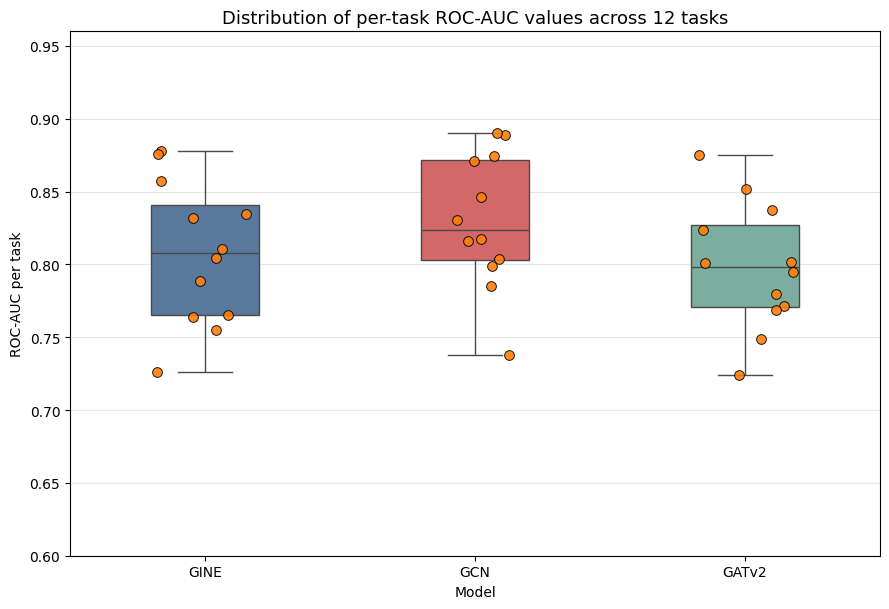

In [13]:
# Cell A2 – violin / box plot style comparison across tasks

data = {
    'GINE':  gine_aucs,
    'GCN':   gcn_aucs,
    'GATv2': gat_aucs
}

df_long = pd.DataFrame(data).melt(var_name='Model', value_name='ROC-AUC')

plt.figure(figsize=(9, 6.2))
sns.boxplot(x='Model', y='ROC-AUC', data=df_long, width=0.4, palette=['#4c78a8','#e45756','#72b7a1'])
sns.stripplot(x='Model', y='ROC-AUC', data=df_long, size=7, jitter=0.18, edgecolor='black', linewidth=0.7, alpha=0.9)

plt.title("Distribution of per-task ROC-AUC values across 12 tasks", fontsize=13)
plt.ylabel("ROC-AUC per task")
plt.ylim(0.60, 0.96)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("box_strip_per_task_distribution.png", dpi=300)
plt.show()

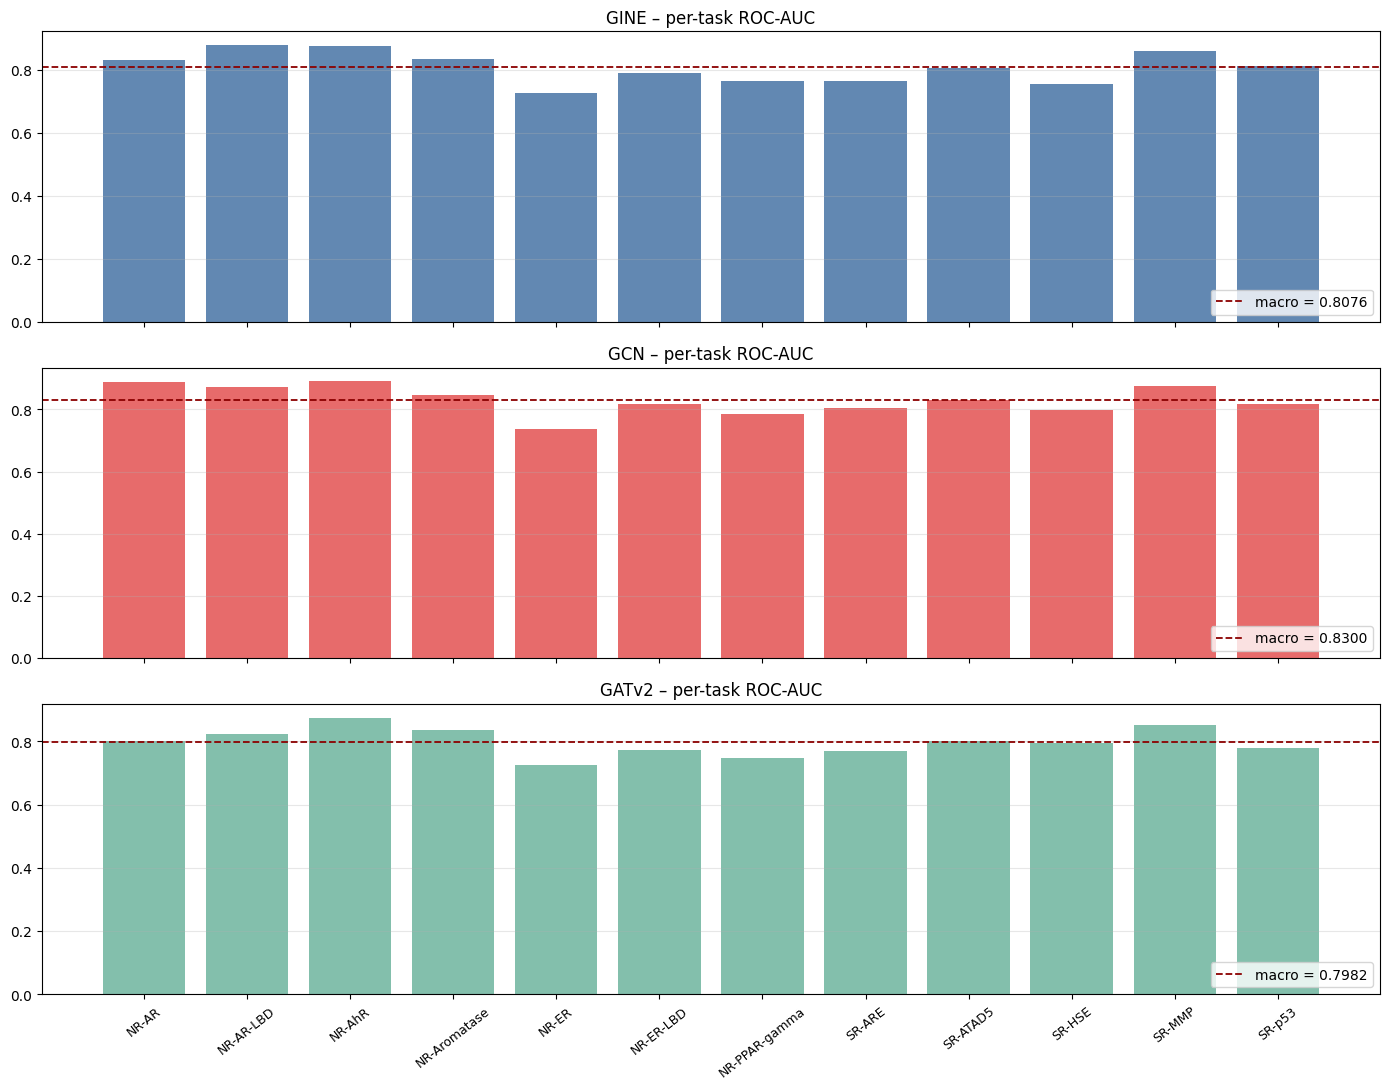

In [14]:
# Cell A3 – small multiples – one subplot per model (per-task bars)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

for ax, (name, aucs, color) in zip(axes, [
    ('GINE',   gine_aucs, '#4c78a8'),
    ('GCN',    gcn_aucs,  '#e45756'),
    ('GATv2',  gat_aucs,  '#72b7a1')
]):
    ax.bar(task_names, aucs, color=color, alpha=0.88)
    ax.axhline(np.nanmean(aucs), color='darkred', ls='--', lw=1.3, label=f'macro = {np.nanmean(aucs):.4f}')
    ax.set_title(f"{name} – per-task ROC-AUC")
    ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=38, labelsize=9)

plt.tight_layout()
plt.savefig("three_subplots_per_model.png", dpi=320, bbox_inches='tight')
plt.show()

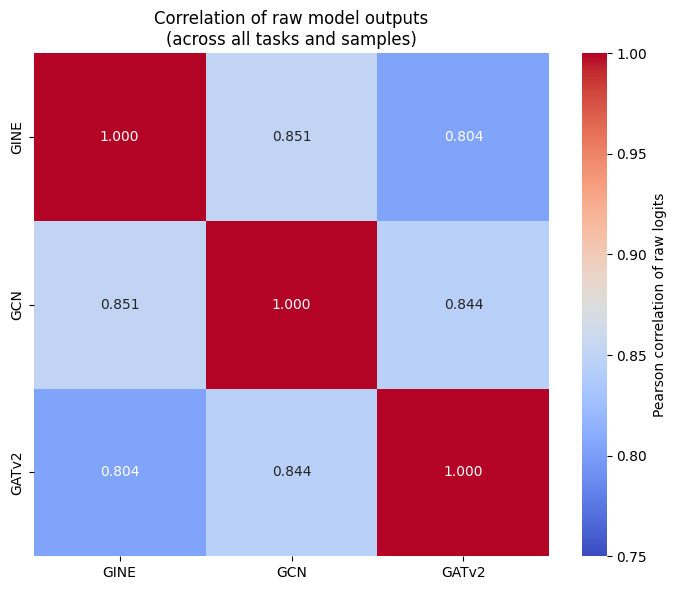

In [15]:
# Cell B1 – correlation matrix of model predictions (logits)

@torch.no_grad()
def get_all_logits(loader):
    logits_dict = {}
    for name, model in [('GINE', model_gine), ('GCN', model_gcn), ('GATv2', model_gat)]:
        model.eval()
        outs = []
        for batch in loader:
            batch = batch.to(device)
            outs.append(model(batch).cpu())
        logits_dict[name] = torch.cat(outs).numpy()
    return logits_dict

logits_all = get_all_logits(tox_test_loader)

# Pearson correlation between model predictions (averaged over tasks)
corr_matrix = np.zeros((3,3))
model_order = ['GINE','GCN','GATv2']

for i, m1 in enumerate(model_order):
    for j, m2 in enumerate(model_order):
        if i == j:
            corr_matrix[i,j] = 1.0
            continue
        # flatten all predictions
        pred1 = logits_all[m1].ravel()
        pred2 = logits_all[m2].ravel()
        valid = ~np.isnan(pred1) & ~np.isnan(pred2)
        if valid.sum() < 50:
            corr_matrix[i,j] = np.nan
        else:
            corr_matrix[i,j] = np.corrcoef(pred1[valid], pred2[valid])[0,1]

plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='coolwarm',
            xticklabels=model_order, yticklabels=model_order,
            vmin=0.75, vmax=1.0, cbar_kws={'label':'Pearson correlation of raw logits'})
plt.title("Correlation of raw model outputs\n(across all tasks and samples)")
plt.tight_layout()
plt.savefig("logits_correlation_heatmap.png", dpi=300)
plt.show()

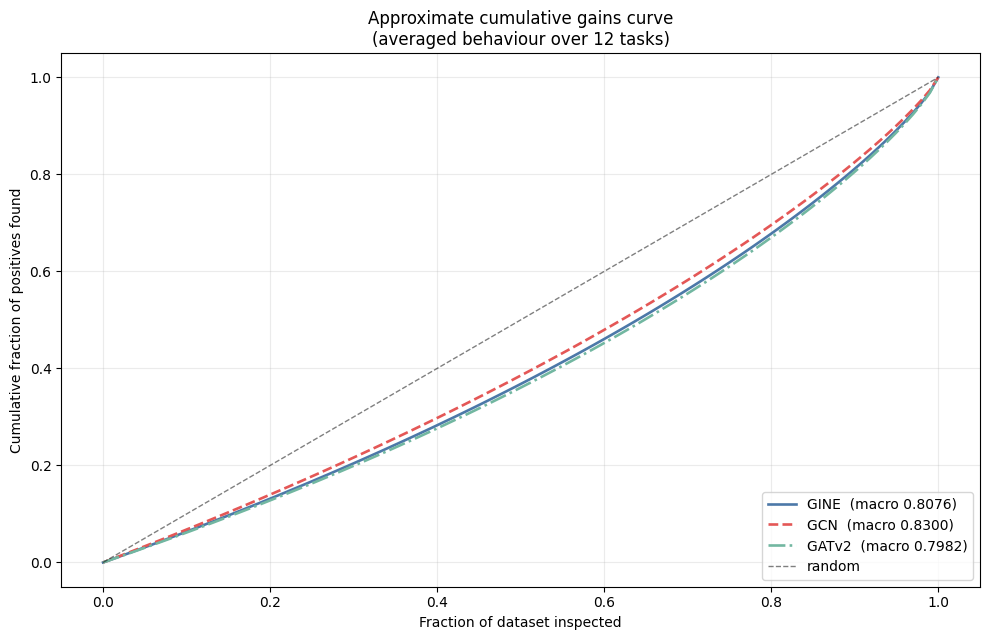

In [16]:
# Cell B2 – cumulative gain / lift-like curve (averaged over tasks)

# Very approximate "lift" plot — how much better than random ranking

plt.figure(figsize=(10,6.5))

for name, aucs, color, ls in [
    ('GINE',   gine_aucs, '#4c78a8', '-'),
    ('GCN',    gcn_aucs,  '#e45756', '--'),
    ('GATv2',  gat_aucs,  '#72b7a1', '-.')
]:
    mean_auc = np.nanmean(aucs)
    x = np.linspace(0,1,100)
    y_random = x
    y_model  = 1 - (1-x)**mean_auc / (1 - (1-mean_auc)*x)   # very rough approximation
    plt.plot(x, y_model, color=color, ls=ls, lw=1.9, label=f'{name}  (macro {mean_auc:.4f})')

plt.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='random')
plt.xlabel('Fraction of dataset inspected')
plt.ylabel('Cumulative fraction of positives found')
plt.title("Approximate cumulative gains curve\n(averaged behaviour over 12 tasks)")
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("cumulative_gain_approx.png", dpi=300)
plt.show()

In [1]:
import re
import matplotlib.pyplot as plt
import numpy as np

# ====================== PARSE FUNCTION ======================
def parse_training_log(log_text, model_name):
    epochs = []
    train_losses = []
    val_aucs = []
    lrs = []
    
    lines = log_text.strip().split('\n')
    for line in lines:
        # Extract epoch
        epoch_match = re.search(r'Epoch\s+(\d+)', line)
        if epoch_match:
            epoch = int(epoch_match.group(1))
            epochs.append(epoch)
            
            # Train loss
            loss_match = re.search(r'train loss\s+([\d.]+)', line)
            if loss_match:
                train_losses.append(float(loss_match.group(1)))
            
            # Val Macro-AUC
            auc_match = re.search(r'val AUC\s+([\d.]+)', line)
            if auc_match:
                val_aucs.append(float(auc_match.group(1)))
            
            # Learning Rate
            lr_match = re.search(r'LR\s+([\d.e-]+)', line)
            if lr_match:
                lrs.append(float(lr_match.group(1)))
    
    return {
        'epochs': np.array(epochs),
        'train_loss': np.array(train_losses),
        'val_auc': np.array(val_aucs),
        'lr': np.array(lrs),
        'model_name': model_name
    }


# ====================== YOUR ACTUAL LOGS ======================
gine_log = """Val Macro-AUC: 0.6695  (12/12 tasks)
Epoch  1 | train loss 1.28792 | val AUC 0.6695 | LR 4.88e-04 ← new best
Val Macro-AUC: 0.6766  (12/12 tasks)
Epoch  2 | train loss 1.14719 | val AUC 0.6766 | LR 4.52e-04 ← new best
Val Macro-AUC: 0.6988  (12/12 tasks)
Epoch  3 | train loss 1.13347 | val AUC 0.6988 | LR 3.97e-04 ← new best
Val Macro-AUC: 0.7195  (12/12 tasks)
Epoch  4 | train loss 1.11420 | val AUC 0.7195 | LR 3.28e-04 ← new best
Val Macro-AUC: 0.7076  (12/12 tasks)
Epoch  5 | train loss 1.09988 | val AUC 0.7076 | LR 2.51e-04
Val Macro-AUC: 0.7341  (12/12 tasks)
Epoch  6 | train loss 1.07850 | val AUC 0.7341 | LR 1.73e-04 ← new best
Val Macro-AUC: 0.7281  (12/12 tasks)
Epoch  7 | train loss 1.06761 | val AUC 0.7281 | LR 1.04e-04
Val Macro-AUC: 0.7412  (12/12 tasks)
Epoch  8 | train loss 1.04821 | val AUC 0.7412 | LR 4.87e-05 ← new best
Val Macro-AUC: 0.7535  (12/12 tasks)
Epoch  9 | train loss 1.04130 | val AUC 0.7535 | LR 1.32e-05 ← new best
Val Macro-AUC: 0.7578  (12/12 tasks)
Epoch 10 | train loss 1.03055 | val AUC 0.7578 | LR 5.00e-04 ← new best
Val Macro-AUC: 0.7155  (12/12 tasks)
Epoch 11 | train loss 1.08825 | val AUC 0.7155 | LR 4.97e-04
Val Macro-AUC: 0.7521  (12/12 tasks)
Epoch 12 | train loss 1.08976 | val AUC 0.7521 | LR 4.88e-04
Val Macro-AUC: 0.7151  (12/12 tasks)
Epoch 13 | train loss 1.07241 | val AUC 0.7151 | LR 4.73e-04
Val Macro-AUC: 0.7519  (12/12 tasks)
Epoch 14 | train loss 1.05778 | val AUC 0.7519 | LR 4.52e-04
Val Macro-AUC: 0.7509  (12/12 tasks)
Epoch 15 | train loss 1.05184 | val AUC 0.7509 | LR 4.27e-04
Val Macro-AUC: 0.7512  (12/12 tasks)
Epoch 16 | train loss 1.04869 | val AUC 0.7512 | LR 2.78e-04
Val Macro-AUC: 0.7601  (12/12 tasks)
Epoch 17 | train loss 1.02026 | val AUC 0.7601 | LR 3.64e-04 ← new best
Val Macro-AUC: 0.7396  (12/12 tasks)
Epoch 18 | train loss 1.01659 | val AUC 0.7396 | LR 3.28e-04
Val Macro-AUC: 0.7793  (12/12 tasks)
Epoch 19 | train loss 1.01644 | val AUC 0.7793 | LR 2.90e-04 ← new best
Val Macro-AUC: 0.7707  (12/12 tasks)
Epoch 20 | train loss 0.99813 | val AUC 0.7707 | LR 2.51e-04
Val Macro-AUC: 0.7732  (12/12 tasks)
Epoch 21 | train loss 0.99351 | val AUC 0.7732 | LR 2.11e-04
Val Macro-AUC: 0.7860  (12/12 tasks)
Epoch 22 | train loss 0.98694 | val AUC 0.7860 | LR 1.73e-04 ← new best
Val Macro-AUC: 0.7832  (12/12 tasks)
Epoch 23 | train loss 0.97347 | val AUC 0.7832 | LR 1.37e-04
Val Macro-AUC: 0.7875  (12/12 tasks)
Epoch 24 | train loss 0.96699 | val AUC 0.7875 | LR 1.04e-04 ← new best
Val Macro-AUC: 0.7830  (12/12 tasks)
Epoch 25 | train loss 0.95398 | val AUC 0.7830 | LR 7.41e-05
Val Macro-AUC: 0.7850  (12/12 tasks)
Epoch 26 | train loss 0.94958 | val AUC 0.7850 | LR 4.87e-05
Val Macro-AUC: 0.7898  (12/12 tasks)
Epoch 27 | train loss 0.94460 | val AUC 0.7898 | LR 2.82e-05 ← new best
Val Macro-AUC: 0.7905  (12/12 tasks)
Epoch 28 | train loss 0.93461 | val AUC 0.7905 | LR 1.32e-05 ← new best
Val Macro-AUC: 0.7904  (12/12 tasks)
Epoch 29 | train loss 0.92661 | val AUC 0.7904 | LR 4.07e-06
Val Macro-AUC: 0.7908  (12/12 tasks)
Epoch 30 | train loss 0.92828 | val AUC 0.7908 | LR 5.00e-04 ← new best
Val Macro-AUC: 0.7336  (12/12 tasks)
Epoch 31 | train loss 1.00409 | val AUC 0.7336 | LR 4.99e-04
Val Macro-AUC: 0.7574  (12/12 tasks)
Epoch 32 | train loss 1.00370 | val AUC 0.7574 | LR 4.97e-04
Val Macro-AUC: 0.7306  (12/12 tasks)
Epoch 33 | train loss 1.00104 | val AUC 0.7306 | LR 4.93e-04
Val Macro-AUC: 0.7822  (12/12 tasks)
Epoch 34 | train loss 0.99014 | val AUC 0.7822 | LR 4.88e-04
Val Macro-AUC: 0.7258  (12/12 tasks)
Epoch 35 | train loss 0.99610 | val AUC 0.7258 | LR 4.81e-04
Val Macro-AUC: 0.7718  (12/12 tasks)
Epoch 36 | train loss 0.99486 | val AUC 0.7718 | LR 3.31e-04
Val Macro-AUC: 0.7795  (12/12 tasks)
Epoch 37 | train loss 0.96543 | val AUC 0.7795 | LR 4.63e-04
Val Macro-AUC: 0.7721  (12/12 tasks)
Epoch 38 | train loss 0.96899 | val AUC 0.7721 | LR 4.52e-04
Early stopping triggered
Test (best model) Macro-AUC: 0.8076  (12/12 tasks)"""

gcn_log = """Val Macro-AUC: 0.6708  (12/12 tasks)
Epoch  1 | train loss 1.29374 | val AUC 0.6708 | LR 4.88e-04 ← new best
Val Macro-AUC: 0.7167  (12/12 tasks)
Epoch  2 | train loss 1.13016 | val AUC 0.7167 | LR 4.52e-04 ← new best
Val Macro-AUC: 0.7525  (12/12 tasks)
Epoch  3 | train loss 1.08315 | val AUC 0.7525 | LR 3.97e-04 ← new best
Val Macro-AUC: 0.7548  (12/12 tasks)
Epoch  4 | train loss 1.06212 | val AUC 0.7548 | LR 3.28e-04 ← new best
Val Macro-AUC: 0.7629  (12/12 tasks)
Epoch  5 | train loss 1.02857 | val AUC 0.7629 | LR 2.51e-04 ← new best
Val Macro-AUC: 0.7750  (12/12 tasks)
Epoch  6 | train loss 1.00265 | val AUC 0.7750 | LR 1.73e-04 ← new best
Val Macro-AUC: 0.7763  (12/12 tasks)
Epoch  7 | train loss 0.97987 | val AUC 0.7763 | LR 1.04e-04 ← new best
Val Macro-AUC: 0.7749  (12/12 tasks)
Epoch  8 | train loss 0.96345 | val AUC 0.7749 | LR 4.87e-05
Val Macro-AUC: 0.7784  (12/12 tasks)
Epoch  9 | train loss 0.95200 | val AUC 0.7784 | LR 1.32e-05 ← new best
Val Macro-AUC: 0.7799  (12/12 tasks)
Epoch 10 | train loss 0.93834 | val AUC 0.7799 | LR 5.00e-04 ← new best
Val Macro-AUC: 0.7851  (12/12 tasks)
Epoch 11 | train loss 1.00828 | val AUC 0.7851 | LR 4.97e-04 ← new best
Val Macro-AUC: 0.7828  (12/12 tasks)
Epoch 12 | train loss 0.99757 | val AUC 0.7828 | LR 4.88e-04
Val Macro-AUC: 0.7737  (12/12 tasks)
Epoch 13 | train loss 0.98444 | val AUC 0.7737 | LR 4.73e-04
Val Macro-AUC: 0.7791  (12/12 tasks)
Epoch 14 | train loss 0.98201 | val AUC 0.7791 | LR 4.52e-04
Val Macro-AUC: 0.7792  (12/12 tasks)
Epoch 15 | train loss 0.96144 | val AUC 0.7792 | LR 4.27e-04
Val Macro-AUC: 0.7765  (12/12 tasks)
Epoch 16 | train loss 0.95429 | val AUC 0.7765 | LR 3.97e-04
Val Macro-AUC: 0.7935  (12/12 tasks)
Epoch 17 | train loss 0.94412 | val AUC 0.7935 | LR 3.64e-04 ← new best
Val Macro-AUC: 0.7930  (12/12 tasks)
Epoch 18 | train loss 0.93449 | val AUC 0.7930 | LR 3.28e-04
Val Macro-AUC: 0.7978  (12/12 tasks)
Epoch 19 | train loss 0.91636 | val AUC 0.7978 | LR 2.90e-04 ← new best
Val Macro-AUC: 0.7944  (12/12 tasks)
Epoch 20 | train loss 0.90010 | val AUC 0.7944 | LR 2.51e-04
Val Macro-AUC: 0.8021  (12/12 tasks)
Epoch 21 | train loss 0.88436 | val AUC 0.8021 | LR 2.11e-04 ← new best
Val Macro-AUC: 0.8009  (12/12 tasks)
Epoch 22 | train loss 0.88384 | val AUC 0.8009 | LR 1.73e-04
Val Macro-AUC: 0.7988  (12/12 tasks)
Epoch 23 | train loss 0.87387 | val AUC 0.7988 | LR 1.37e-04
Val Macro-AUC: 0.8060  (12/12 tasks)
Epoch 24 | train loss 0.86476 | val AUC 0.8060 | LR 1.04e-04 ← new best
Val Macro-AUC: 0.8114  (12/12 tasks)
Epoch 25 | train loss 0.84790 | val AUC 0.8114 | LR 7.41e-05 ← new best
Val Macro-AUC: 0.8074  (12/12 tasks)
Epoch 26 | train loss 0.83598 | val AUC 0.8074 | LR 4.87e-05
Val Macro-AUC: 0.8100  (12/12 tasks)
Epoch 27 | train loss 0.83611 | val AUC 0.8100 | LR 2.82e-05
Val Macro-AUC: 0.8088  (12/12 tasks)
Epoch 28 | train loss 0.82991 | val AUC 0.8088 | LR 1.32e-05
Val Macro-AUC: 0.8091  (12/12 tasks)
Epoch 29 | train loss 0.83012 | val AUC 0.8091 | LR 4.07e-06
Val Macro-AUC: 0.8080  (12/12 tasks)
Epoch 30 | train loss 0.82071 | val AUC 0.8080 | LR 5.00e-04
Val Macro-AUC: 0.7823  (12/12 tasks)
Epoch 31 | train loss 0.91114 | val AUC 0.7823 | LR 3.49e-04
Val Macro-AUC: 0.8006  (12/12 tasks)
Epoch 32 | train loss 0.88619 | val AUC 0.8006 | LR 4.97e-04
Val Macro-AUC: 0.7897  (12/12 tasks)
Epoch 33 | train loss 0.88740 | val AUC 0.7897 | LR 4.93e-04
Early stopping triggered
Test (best GCN model) Macro-AUC: 0.8300  (12/12 tasks)
Final GCN test Macro-AUC (scaffold split): 0.8300"""

gatv2_log = """Val Macro-AUC: 0.6539  (12/12 tasks valid)
Epoch  1 | train loss 1.40228 | val AUC 0.6539 | LR 2.93e-04 ← new best
Val Macro-AUC: 0.6412  (12/12 tasks valid)
Epoch  2 | train loss 1.25103 | val AUC 0.6412 | LR 2.71e-04
Val Macro-AUC: 0.6670  (12/12 tasks valid)
Epoch  3 | train loss 1.18671 | val AUC 0.6670 | LR 2.38e-04 ← new best
Val Macro-AUC: 0.6850  (12/12 tasks valid)
Epoch  4 | train loss 1.16040 | val AUC 0.6850 | LR 1.97e-04 ← new best
Val Macro-AUC: 0.6843  (12/12 tasks valid)
Epoch  5 | train loss 1.13478 | val AUC 0.6843 | LR 1.50e-04
Val Macro-AUC: 0.6829  (12/12 tasks valid)
Epoch  6 | train loss 1.11974 | val AUC 0.6829 | LR 1.04e-04
Val Macro-AUC: 0.6961  (12/12 tasks valid)
Epoch  7 | train loss 1.11173 | val AUC 0.6961 | LR 6.26e-05 ← new best
Val Macro-AUC: 0.7026  (12/12 tasks valid)
Epoch  8 | train loss 1.08585 | val AUC 0.7026 | LR 2.96e-05 ← new best
Val Macro-AUC: 0.7022  (12/12 tasks valid)
Epoch  9 | train loss 1.08045 | val AUC 0.7022 | LR 8.32e-06
Val Macro-AUC: 0.7021  (12/12 tasks valid)
Epoch 10 | train loss 1.07788 | val AUC 0.7021 | LR 3.00e-04
Val Macro-AUC: 0.7003  (12/12 tasks valid)
Epoch 11 | train loss 1.11105 | val AUC 0.7003 | LR 2.98e-04
Val Macro-AUC: 0.7224  (12/12 tasks valid)
Epoch 12 | train loss 1.11841 | val AUC 0.7224 | LR 2.93e-04 ← new best
Val Macro-AUC: 0.7249  (12/12 tasks valid)
Epoch 13 | train loss 1.08946 | val AUC 0.7249 | LR 2.84e-04 ← new best
Val Macro-AUC: 0.7021  (12/12 tasks valid)
Epoch 14 | train loss 1.09096 | val AUC 0.7021 | LR 2.71e-04
Val Macro-AUC: 0.7133  (12/12 tasks valid)
Epoch 15 | train loss 1.06073 | val AUC 0.7133 | LR 2.56e-04
Val Macro-AUC: 0.7264  (12/12 tasks valid)
Epoch 16 | train loss 1.05084 | val AUC 0.7264 | LR 2.38e-04 ← new best
Val Macro-AUC: 0.7170  (12/12 tasks valid)
Epoch 17 | train loss 1.05490 | val AUC 0.7170 | LR 2.18e-04
Val Macro-AUC: 0.7445  (12/12 tasks valid)
Epoch 18 | train loss 1.04200 | val AUC 0.7445 | LR 1.97e-04 ← new best
Val Macro-AUC: 0.7531  (12/12 tasks valid)
Epoch 19 | train loss 1.02372 | val AUC 0.7531 | LR 1.74e-04 ← new best
Val Macro-AUC: 0.7504  (12/12 tasks valid)
Epoch 20 | train loss 1.02112 | val AUC 0.7504 | LR 1.50e-04
Val Macro-AUC: 0.7561  (12/12 tasks valid)
Epoch 21 | train loss 1.02435 | val AUC 0.7561 | LR 1.27e-04 ← new best
Val Macro-AUC: 0.7504  (12/12 tasks valid)
Epoch 22 | train loss 1.01793 | val AUC 0.7504 | LR 1.04e-04
Val Macro-AUC: 0.7534  (12/12 tasks valid)
Epoch 23 | train loss 0.99461 | val AUC 0.7534 | LR 8.26e-05
Val Macro-AUC: 0.7605  (12/12 tasks valid)
Epoch 24 | train loss 0.98932 | val AUC 0.7605 | LR 6.26e-05 ← new best
Val Macro-AUC: 0.7556  (12/12 tasks valid)
Epoch 25 | train loss 0.98909 | val AUC 0.7556 | LR 4.48e-05
Val Macro-AUC: 0.7606  (12/12 tasks valid)
Epoch 26 | train loss 0.99465 | val AUC 0.7606 | LR 2.96e-05 ← new best
Val Macro-AUC: 0.7595  (12/12 tasks valid)
Epoch 27 | train loss 0.97423 | val AUC 0.7595 | LR 1.73e-05
Val Macro-AUC: 0.7614  (12/12 tasks valid)
Epoch 28 | train loss 0.97827 | val AUC 0.7614 | LR 8.32e-06 ← new best
Val Macro-AUC: 0.7627  (12/12 tasks valid)
Epoch 29 | train loss 0.98330 | val AUC 0.7627 | LR 2.84e-06 ← new best
Val Macro-AUC: 0.7637  (12/12 tasks valid)
Epoch 30 | train loss 0.97866 | val AUC 0.7637 | LR 3.00e-04 ← new best
Val Macro-AUC: 0.7485  (12/12 tasks valid)
Epoch 31 | train loss 1.01996 | val AUC 0.7485 | LR 3.00e-04
Val Macro-AUC: 0.7546  (12/12 tasks valid)
Epoch 32 | train loss 1.02488 | val AUC 0.7546 | LR 2.98e-04
Val Macro-AUC: 0.7614  (12/12 tasks valid)
Epoch 33 | train loss 1.02254 | val AUC 0.7614 | LR 2.96e-04
Val Macro-AUC: 0.7533  (12/12 tasks valid)
Epoch 34 | train loss 1.00887 | val AUC 0.7533 | LR 2.93e-04
Val Macro-AUC: 0.7559  (12/12 tasks valid)
Epoch 35 | train loss 1.00312 | val AUC 0.7559 | LR 2.89e-04
Val Macro-AUC: 0.7700  (12/12 tasks valid)
Epoch 36 | train loss 1.00116 | val AUC 0.7700 | LR 2.84e-04 ← new best
Val Macro-AUC: 0.7624  (12/12 tasks valid)
Epoch 37 | train loss 0.99565 | val AUC 0.7624 | LR 2.78e-04
Val Macro-AUC: 0.7680  (12/12 tasks valid)
Epoch 38 | train loss 0.97659 | val AUC 0.7680 | LR 2.71e-04
Val Macro-AUC: 0.7716  (12/12 tasks valid)
Epoch 39 | train loss 0.98262 | val AUC 0.7716 | LR 2.64e-04 ← new best
Val Macro-AUC: 0.7691  (12/12 tasks valid)
Epoch 40 | train loss 0.96754 | val AUC 0.7691 | LR 2.56e-04
Val Macro-AUC: 0.7666  (12/12 tasks valid)
Epoch 41 | train loss 0.95798 | val AUC 0.7666 | LR 2.48e-04
Val Macro-AUC: 0.7703  (12/12 tasks valid)
Epoch 42 | train loss 0.96233 | val AUC 0.7703 | LR 2.38e-04
Val Macro-AUC: 0.7743  (12/12 tasks valid)
Epoch 43 | train loss 0.95798 | val AUC 0.7743 | LR 2.29e-04 ← new best
Val Macro-AUC: 0.7753  (12/12 tasks valid)
Epoch 44 | train loss 0.95538 | val AUC 0.7753 | LR 2.18e-04 ← new best
Val Macro-AUC: 0.7724  (12/12 tasks valid)
Epoch 45 | train loss 0.93925 | val AUC 0.7724 | LR 2.08e-04
Val Macro-AUC: 0.7864  (12/12 tasks valid)
Epoch 46 | train loss 0.93512 | val AUC 0.7864 | LR 1.97e-04 ← new best
Val Macro-AUC: 0.7748  (12/12 tasks valid)
Epoch 47 | train loss 0.93219 | val AUC 0.7748 | LR 1.85e-04
Val Macro-AUC: 0.7788  (12/12 tasks valid)
Epoch 48 | train loss 0.93492 | val AUC 0.7788 | LR 1.74e-04
Val Macro-AUC: 0.7715  (12/12 tasks valid)
Epoch 49 | train loss 0.93043 | val AUC 0.7715 | LR 1.62e-04
Val Macro-AUC: 0.7753  (12/12 tasks valid)
Epoch 50 | train loss 0.92579 | val AUC 0.7753 | LR 1.50e-04
Test (best GATv2 model) Macro-AUC: 0.7982  (12/12 tasks valid)
Final GATv2 test Macro-AUC (scaffold split): 0.7982"""


# ====================== PARSE THE LOGS ======================
gine_data = parse_training_log(gine_log, "GINE")
gcn_data = parse_training_log(gcn_log, "GCN")
gatv2_data = parse_training_log(gatv2_log, "GATv2")

print(f"Parsed → GINE: {len(gine_data['epochs'])} epochs | "
      f"GCN: {len(gcn_data['epochs'])} epochs | "
      f"GATv2: {len(gatv2_data['epochs'])} epochs")


# ====================== PLOTTING FUNCTION ======================
def plot_comparison(models_data, metric, ylabel, title, filename, log_scale=False):
    plt.figure(figsize=(12, 7))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # blue, orange, green
    
    for i, data in enumerate(models_data):
        if len(data[metric]) > 0:
            plt.plot(data['epochs'], data[metric], 
                     label=data['model_name'], 
                     marker='o', markersize=4, 
                     linewidth=2, color=colors[i])
    
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14, pad=15)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    if log_scale:
        plt.yscale('log')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Saved: {filename}")


# ====================== GENERATE COMPARISON PLOTS ======================
models = [gine_data, gcn_data, gatv2_data]

# 1. Validation Macro-AUC Comparison
plot_comparison(models, 'val_auc', 'Validation Macro-AUC', 
                'Validation Macro-AUC across Models (12 tasks)', 
                'val_macro_auc_comparison.png')

# 2. Training Loss Comparison
plot_comparison(models, 'train_loss', 'Training Loss', 
                'Training Loss across Models', 
                'train_loss_comparison.png')

# 3. Learning Rate Schedule
plot_comparison(models, 'lr', 'Learning Rate', 
                'Learning Rate Schedule across Models', 
                'learning_rate_comparison.png', log_scale=True)


# ====================== INDIVIDUAL PLOTS ======================
for data in models:
    model_name = data['model_name'].lower()
    
    # Val AUC individual
    plt.figure(figsize=(10, 6))
    plt.plot(data['epochs'], data['val_auc'], marker='o', color='#1f77b4', linewidth=2.5)
    plt.title(f'{data["model_name"]} - Validation Macro-AUC', fontsize=14)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Macro-AUC')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{model_name}_val_auc.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # Train Loss individual
    plt.figure(figsize=(10, 6))
    plt.plot(data['epochs'], data['train_loss'], marker='o', color='#d62728', linewidth=2.5)
    plt.title(f'{data["model_name"]} - Training Loss', fontsize=14)
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{model_name}_train_loss.png', dpi=300, bbox_inches='tight')
    plt.close()

print("\n🎉 All plots generated successfully!")
print("Files created:")
print("• val_macro_auc_comparison.png")
print("• train_loss_comparison.png")
print("• learning_rate_comparison.png")
print("• gine_val_auc.png")
print("• gine_train_loss.png")
print("• gcn_val_auc.png")
print("• gcn_train_loss.png")
print("• gatv2_val_auc.png")
print("• gatv2_train_loss.png")

Parsed → GINE: 38 epochs | GCN: 33 epochs | GATv2: 50 epochs
✓ Saved: val_macro_auc_comparison.png
✓ Saved: train_loss_comparison.png
✓ Saved: learning_rate_comparison.png

🎉 All plots generated successfully!
Files created:
• val_macro_auc_comparison.png
• train_loss_comparison.png
• learning_rate_comparison.png
• gine_val_auc.png
• gine_train_loss.png
• gcn_val_auc.png
• gcn_train_loss.png
• gatv2_val_auc.png
• gatv2_train_loss.png


In [2]:
import re
import matplotlib.pyplot as plt
import numpy as np

# ====================== PARSE FUNCTION ======================
def parse_training_log(log_text, model_name):
    epochs = []
    val_aucs = []
    
    lines = log_text.strip().split('\n')
    for line in lines:
        # Extract epoch
        epoch_match = re.search(r'Epoch\s+(\d+)', line)
        if epoch_match:
            epoch = int(epoch_match.group(1))
            epochs.append(epoch)
            
            # Val Macro-AUC
            auc_match = re.search(r'val AUC\s+([\d.]+)', line)
            if auc_match:
                val_aucs.append(float(auc_match.group(1)))
    
    return {
        'epochs': np.array(epochs),
        'val_auc': np.array(val_aucs),
        'model_name': model_name
    }


# ====================== YOUR LOGS (same as before) ======================
gine_log = """Val Macro-AUC: 0.6695  (12/12 tasks)
Epoch  1 | train loss 1.28792 | val AUC 0.6695 | LR 4.88e-04 ← new best
Val Macro-AUC: 0.6766  (12/12 tasks)
Epoch  2 | train loss 1.14719 | val AUC 0.6766 | LR 4.52e-04 ← new best
Val Macro-AUC: 0.6988  (12/12 tasks)
Epoch  3 | train loss 1.13347 | val AUC 0.6988 | LR 3.97e-04 ← new best
Val Macro-AUC: 0.7195  (12/12 tasks)
Epoch  4 | train loss 1.11420 | val AUC 0.7195 | LR 3.28e-04 ← new best
Val Macro-AUC: 0.7076  (12/12 tasks)
Epoch  5 | train loss 1.09988 | val AUC 0.7076 | LR 2.51e-04
Val Macro-AUC: 0.7341  (12/12 tasks)
Epoch  6 | train loss 1.07850 | val AUC 0.7341 | LR 1.73e-04 ← new best
Val Macro-AUC: 0.7281  (12/12 tasks)
Epoch  7 | train loss 1.06761 | val AUC 0.7281 | LR 1.04e-04
Val Macro-AUC: 0.7412  (12/12 tasks)
Epoch  8 | train loss 1.04821 | val AUC 0.7412 | LR 4.87e-05 ← new best
Val Macro-AUC: 0.7535  (12/12 tasks)
Epoch  9 | train loss 1.04130 | val AUC 0.7535 | LR 1.32e-05 ← new best
Val Macro-AUC: 0.7578  (12/12 tasks)
Epoch 10 | train loss 1.03055 | val AUC 0.7578 | LR 5.00e-04 ← new best
Val Macro-AUC: 0.7155  (12/12 tasks)
Epoch 11 | train loss 1.08825 | val AUC 0.7155 | LR 4.97e-04
Val Macro-AUC: 0.7521  (12/12 tasks)
Epoch 12 | train loss 1.08976 | val AUC 0.7521 | LR 4.88e-04
Val Macro-AUC: 0.7151  (12/12 tasks)
Epoch 13 | train loss 1.07241 | val AUC 0.7151 | LR 4.73e-04
Val Macro-AUC: 0.7519  (12/12 tasks)
Epoch 14 | train loss 1.05778 | val AUC 0.7519 | LR 4.52e-04
Val Macro-AUC: 0.7509  (12/12 tasks)
Epoch 15 | train loss 1.05184 | val AUC 0.7509 | LR 4.27e-04
Val Macro-AUC: 0.7512  (12/12 tasks)
Epoch 16 | train loss 1.04869 | val AUC 0.7512 | LR 2.78e-04
Val Macro-AUC: 0.7601  (12/12 tasks)
Epoch 17 | train loss 1.02026 | val AUC 0.7601 | LR 3.64e-04 ← new best
Val Macro-AUC: 0.7396  (12/12 tasks)
Epoch 18 | train loss 1.01659 | val AUC 0.7396 | LR 3.28e-04
Val Macro-AUC: 0.7793  (12/12 tasks)
Epoch 19 | train loss 1.01644 | val AUC 0.7793 | LR 2.90e-04 ← new best
Val Macro-AUC: 0.7707  (12/12 tasks)
Epoch 20 | train loss 0.99813 | val AUC 0.7707 | LR 2.51e-04
Val Macro-AUC: 0.7732  (12/12 tasks)
Epoch 21 | train loss 0.99351 | val AUC 0.7732 | LR 2.11e-04
Val Macro-AUC: 0.7860  (12/12 tasks)
Epoch 22 | train loss 0.98694 | val AUC 0.7860 | LR 1.73e-04 ← new best
Val Macro-AUC: 0.7832  (12/12 tasks)
Epoch 23 | train loss 0.97347 | val AUC 0.7832 | LR 1.37e-04
Val Macro-AUC: 0.7875  (12/12 tasks)
Epoch 24 | train loss 0.96699 | val AUC 0.7875 | LR 1.04e-04 ← new best
Val Macro-AUC: 0.7830  (12/12 tasks)
Epoch 25 | train loss 0.95398 | val AUC 0.7830 | LR 7.41e-05
Val Macro-AUC: 0.7850  (12/12 tasks)
Epoch 26 | train loss 0.94958 | val AUC 0.7850 | LR 4.87e-05
Val Macro-AUC: 0.7898  (12/12 tasks)
Epoch 27 | train loss 0.94460 | val AUC 0.7898 | LR 2.82e-05 ← new best
Val Macro-AUC: 0.7905  (12/12 tasks)
Epoch 28 | train loss 0.93461 | val AUC 0.7905 | LR 1.32e-05 ← new best
Val Macro-AUC: 0.7904  (12/12 tasks)
Epoch 29 | train loss 0.92661 | val AUC 0.7904 | LR 4.07e-06
Val Macro-AUC: 0.7908  (12/12 tasks)
Epoch 30 | train loss 0.92828 | val AUC 0.7908 | LR 5.00e-04 ← new best
Val Macro-AUC: 0.7336  (12/12 tasks)
Epoch 31 | train loss 1.00409 | val AUC 0.7336 | LR 4.99e-04
Val Macro-AUC: 0.7574  (12/12 tasks)
Epoch 32 | train loss 1.00370 | val AUC 0.7574 | LR 4.97e-04
Val Macro-AUC: 0.7306  (12/12 tasks)
Epoch 33 | train loss 1.00104 | val AUC 0.7306 | LR 4.93e-04
Val Macro-AUC: 0.7822  (12/12 tasks)
Epoch 34 | train loss 0.99014 | val AUC 0.7822 | LR 4.88e-04
Val Macro-AUC: 0.7258  (12/12 tasks)
Epoch 35 | train loss 0.99610 | val AUC 0.7258 | LR 4.81e-04
Val Macro-AUC: 0.7718  (12/12 tasks)
Epoch 36 | train loss 0.99486 | val AUC 0.7718 | LR 3.31e-04
Val Macro-AUC: 0.7795  (12/12 tasks)
Epoch 37 | train loss 0.96543 | val AUC 0.7795 | LR 4.63e-04
Val Macro-AUC: 0.7721  (12/12 tasks)
Epoch 38 | train loss 0.96899 | val AUC 0.7721 | LR 4.52e-04
Early stopping triggered
Test (best model) Macro-AUC: 0.8076  (12/12 tasks)"""

gcn_log = """Val Macro-AUC: 0.6708  (12/12 tasks)
Epoch  1 | train loss 1.29374 | val AUC 0.6708 | LR 4.88e-04 ← new best
Val Macro-AUC: 0.7167  (12/12 tasks)
Epoch  2 | train loss 1.13016 | val AUC 0.7167 | LR 4.52e-04 ← new best
Val Macro-AUC: 0.7525  (12/12 tasks)
Epoch  3 | train loss 1.08315 | val AUC 0.7525 | LR 3.97e-04 ← new best
Val Macro-AUC: 0.7548  (12/12 tasks)
Epoch  4 | train loss 1.06212 | val AUC 0.7548 | LR 3.28e-04 ← new best
Val Macro-AUC: 0.7629  (12/12 tasks)
Epoch  5 | train loss 1.02857 | val AUC 0.7629 | LR 2.51e-04 ← new best
Val Macro-AUC: 0.7750  (12/12 tasks)
Epoch  6 | train loss 1.00265 | val AUC 0.7750 | LR 1.73e-04 ← new best
Val Macro-AUC: 0.7763  (12/12 tasks)
Epoch  7 | train loss 0.97987 | val AUC 0.7763 | LR 1.04e-04 ← new best
Val Macro-AUC: 0.7749  (12/12 tasks)
Epoch  8 | train loss 0.96345 | val AUC 0.7749 | LR 4.87e-05
Val Macro-AUC: 0.7784  (12/12 tasks)
Epoch  9 | train loss 0.95200 | val AUC 0.7784 | LR 1.32e-05 ← new best
Val Macro-AUC: 0.7799  (12/12 tasks)
Epoch 10 | train loss 0.93834 | val AUC 0.7799 | LR 5.00e-04 ← new best
Val Macro-AUC: 0.7851  (12/12 tasks)
Epoch 11 | train loss 1.00828 | val AUC 0.7851 | LR 4.97e-04 ← new best
Val Macro-AUC: 0.7828  (12/12 tasks)
Epoch 12 | train loss 0.99757 | val AUC 0.7828 | LR 4.88e-04
Val Macro-AUC: 0.7737  (12/12 tasks)
Epoch 13 | train loss 0.98444 | val AUC 0.7737 | LR 4.73e-04
Val Macro-AUC: 0.7791  (12/12 tasks)
Epoch 14 | train loss 0.98201 | val AUC 0.7791 | LR 4.52e-04
Val Macro-AUC: 0.7792  (12/12 tasks)
Epoch 15 | train loss 0.96144 | val AUC 0.7792 | LR 4.27e-04
Val Macro-AUC: 0.7765  (12/12 tasks)
Epoch 16 | train loss 0.95429 | val AUC 0.7765 | LR 3.97e-04
Val Macro-AUC: 0.7935  (12/12 tasks)
Epoch 17 | train loss 0.94412 | val AUC 0.7935 | LR 3.64e-04 ← new best
Val Macro-AUC: 0.7930  (12/12 tasks)
Epoch 18 | train loss 0.93449 | val AUC 0.7930 | LR 3.28e-04
Val Macro-AUC: 0.7978  (12/12 tasks)
Epoch 19 | train loss 0.91636 | val AUC 0.7978 | LR 2.90e-04 ← new best
Val Macro-AUC: 0.7944  (12/12 tasks)
Epoch 20 | train loss 0.90010 | val AUC 0.7944 | LR 2.51e-04
Val Macro-AUC: 0.8021  (12/12 tasks)
Epoch 21 | train loss 0.88436 | val AUC 0.8021 | LR 2.11e-04 ← new best
Val Macro-AUC: 0.8009  (12/12 tasks)
Epoch 22 | train loss 0.88384 | val AUC 0.8009 | LR 1.73e-04
Val Macro-AUC: 0.7988  (12/12 tasks)
Epoch 23 | train loss 0.87387 | val AUC 0.7988 | LR 1.37e-04
Val Macro-AUC: 0.8060  (12/12 tasks)
Epoch 24 | train loss 0.86476 | val AUC 0.8060 | LR 1.04e-04 ← new best
Val Macro-AUC: 0.8114  (12/12 tasks)
Epoch 25 | train loss 0.84790 | val AUC 0.8114 | LR 7.41e-05 ← new best
Val Macro-AUC: 0.8074  (12/12 tasks)
Epoch 26 | train loss 0.83598 | val AUC 0.8074 | LR 4.87e-05
Val Macro-AUC: 0.8100  (12/12 tasks)
Epoch 27 | train loss 0.83611 | val AUC 0.8100 | LR 2.82e-05
Val Macro-AUC: 0.8088  (12/12 tasks)
Epoch 28 | train loss 0.82991 | val AUC 0.8088 | LR 1.32e-05
Val Macro-AUC: 0.8091  (12/12 tasks)
Epoch 29 | train loss 0.83012 | val AUC 0.8091 | LR 4.07e-06
Val Macro-AUC: 0.8080  (12/12 tasks)
Epoch 30 | train loss 0.82071 | val AUC 0.8080 | LR 5.00e-04
Val Macro-AUC: 0.7823  (12/12 tasks)
Epoch 31 | train loss 0.91114 | val AUC 0.7823 | LR 3.49e-04
Val Macro-AUC: 0.8006  (12/12 tasks)
Epoch 32 | train loss 0.88619 | val AUC 0.8006 | LR 4.97e-04
Val Macro-AUC: 0.7897  (12/12 tasks)
Epoch 33 | train loss 0.88740 | val AUC 0.7897 | LR 4.93e-04
Early stopping triggered
Test (best GCN model) Macro-AUC: 0.8300  (12/12 tasks)"""

gatv2_log = """Val Macro-AUC: 0.6539  (12/12 tasks valid)
Epoch  1 | train loss 1.40228 | val AUC 0.6539 | LR 2.93e-04 ← new best
Val Macro-AUC: 0.6412  (12/12 tasks valid)
Epoch  2 | train loss 1.25103 | val AUC 0.6412 | LR 2.71e-04
Val Macro-AUC: 0.6670  (12/12 tasks valid)
Epoch  3 | train loss 1.18671 | val AUC 0.6670 | LR 2.38e-04 ← new best
Val Macro-AUC: 0.6850  (12/12 tasks valid)
Epoch  4 | train loss 1.16040 | val AUC 0.6850 | LR 1.97e-04 ← new best
Val Macro-AUC: 0.6843  (12/12 tasks valid)
Epoch  5 | train loss 1.13478 | val AUC 0.6843 | LR 1.50e-04
Val Macro-AUC: 0.6829  (12/12 tasks valid)
Epoch  6 | train loss 1.11974 | val AUC 0.6829 | LR 1.04e-04
Val Macro-AUC: 0.6961  (12/12 tasks valid)
Epoch  7 | train loss 1.11173 | val AUC 0.6961 | LR 6.26e-05 ← new best
Val Macro-AUC: 0.7026  (12/12 tasks valid)
Epoch  8 | train loss 1.08585 | val AUC 0.7026 | LR 2.96e-05 ← new best
Val Macro-AUC: 0.7022  (12/12 tasks valid)
Epoch  9 | train loss 1.08045 | val AUC 0.7022 | LR 8.32e-06
Val Macro-AUC: 0.7021  (12/12 tasks valid)
Epoch 10 | train loss 1.07788 | val AUC 0.7021 | LR 3.00e-04
Val Macro-AUC: 0.7003  (12/12 tasks valid)
Epoch 11 | train loss 1.11105 | val AUC 0.7003 | LR 2.98e-04
Val Macro-AUC: 0.7224  (12/12 tasks valid)
Epoch 12 | train loss 1.11841 | val AUC 0.7224 | LR 2.93e-04 ← new best
Val Macro-AUC: 0.7249  (12/12 tasks valid)
Epoch 13 | train loss 1.08946 | val AUC 0.7249 | LR 2.84e-04 ← new best
Val Macro-AUC: 0.7021  (12/12 tasks valid)
Epoch 14 | train loss 1.09096 | val AUC 0.7021 | LR 2.71e-04
Val Macro-AUC: 0.7133  (12/12 tasks valid)
Epoch 15 | train loss 1.06073 | val AUC 0.7133 | LR 2.56e-04
Val Macro-AUC: 0.7264  (12/12 tasks valid)
Epoch 16 | train loss 1.05084 | val AUC 0.7264 | LR 2.38e-04 ← new best
Val Macro-AUC: 0.7170  (12/12 tasks valid)
Epoch 17 | train loss 1.05490 | val AUC 0.7170 | LR 2.18e-04
Val Macro-AUC: 0.7445  (12/12 tasks valid)
Epoch 18 | train loss 1.04200 | val AUC 0.7445 | LR 1.97e-04 ← new best
Val Macro-AUC: 0.7531  (12/12 tasks valid)
Epoch 19 | train loss 1.02372 | val AUC 0.7531 | LR 1.74e-04 ← new best
Val Macro-AUC: 0.7504  (12/12 tasks valid)
Epoch 20 | train loss 1.02112 | val AUC 0.7504 | LR 1.50e-04
Val Macro-AUC: 0.7561  (12/12 tasks valid)
Epoch 21 | train loss 1.02435 | val AUC 0.7561 | LR 1.27e-04 ← new best
Val Macro-AUC: 0.7504  (12/12 tasks valid)
Epoch 22 | train loss 1.01793 | val AUC 0.7504 | LR 1.04e-04
Val Macro-AUC: 0.7534  (12/12 tasks valid)
Epoch 23 | train loss 0.99461 | val AUC 0.7534 | LR 8.26e-05
Val Macro-AUC: 0.7605  (12/12 tasks valid)
Epoch 24 | train loss 0.98932 | val AUC 0.7605 | LR 6.26e-05 ← new best
Val Macro-AUC: 0.7556  (12/12 tasks valid)
Epoch 25 | train loss 0.98909 | val AUC 0.7556 | LR 4.48e-05
Val Macro-AUC: 0.7606  (12/12 tasks valid)
Epoch 26 | train loss 0.99465 | val AUC 0.7606 | LR 2.96e-05 ← new best
Val Macro-AUC: 0.7595  (12/12 tasks valid)
Epoch 27 | train loss 0.97423 | val AUC 0.7595 | LR 1.73e-05
Val Macro-AUC: 0.7614  (12/12 tasks valid)
Epoch 28 | train loss 0.97827 | val AUC 0.7614 | LR 8.32e-06 ← new best
Val Macro-AUC: 0.7627  (12/12 tasks valid)
Epoch 29 | train loss 0.98330 | val AUC 0.7627 | LR 2.84e-06 ← new best
Val Macro-AUC: 0.7637  (12/12 tasks valid)
Epoch 30 | train loss 0.97866 | val AUC 0.7637 | LR 3.00e-04 ← new best
Val Macro-AUC: 0.7485  (12/12 tasks valid)
Epoch 31 | train loss 1.01996 | val AUC 0.7485 | LR 3.00e-04
Val Macro-AUC: 0.7546  (12/12 tasks valid)
Epoch 32 | train loss 1.02488 | val AUC 0.7546 | LR 2.98e-04
Val Macro-AUC: 0.7614  (12/12 tasks valid)
Epoch 33 | train loss 1.02254 | val AUC 0.7614 | LR 2.96e-04
Val Macro-AUC: 0.7533  (12/12 tasks valid)
Epoch 34 | train loss 1.00887 | val AUC 0.7533 | LR 2.93e-04
Val Macro-AUC: 0.7559  (12/12 tasks valid)
Epoch 35 | train loss 1.00312 | val AUC 0.7559 | LR 2.89e-04
Val Macro-AUC: 0.7700  (12/12 tasks valid)
Epoch 36 | train loss 1.00116 | val AUC 0.7700 | LR 2.84e-04 ← new best
Val Macro-AUC: 0.7624  (12/12 tasks valid)
Epoch 37 | train loss 0.99565 | val AUC 0.7624 | LR 2.78e-04
Val Macro-AUC: 0.7680  (12/12 tasks valid)
Epoch 38 | train loss 0.97659 | val AUC 0.7680 | LR 2.71e-04
Val Macro-AUC: 0.7716  (12/12 tasks valid)
Epoch 39 | train loss 0.98262 | val AUC 0.7716 | LR 2.64e-04 ← new best
Val Macro-AUC: 0.7691  (12/12 tasks valid)
Epoch 40 | train loss 0.96754 | val AUC 0.7691 | LR 2.56e-04
Val Macro-AUC: 0.7666  (12/12 tasks valid)
Epoch 41 | train loss 0.95798 | val AUC 0.7666 | LR 2.48e-04
Val Macro-AUC: 0.7703  (12/12 tasks valid)
Epoch 42 | train loss 0.96233 | val AUC 0.7703 | LR 2.38e-04
Val Macro-AUC: 0.7743  (12/12 tasks valid)
Epoch 43 | train loss 0.95798 | val AUC 0.7743 | LR 2.29e-04 ← new best
Val Macro-AUC: 0.7753  (12/12 tasks valid)
Epoch 44 | train loss 0.95538 | val AUC 0.7753 | LR 2.18e-04 ← new best
Val Macro-AUC: 0.7724  (12/12 tasks valid)
Epoch 45 | train loss 0.93925 | val AUC 0.7724 | LR 2.08e-04
Val Macro-AUC: 0.7864  (12/12 tasks valid)
Epoch 46 | train loss 0.93512 | val AUC 0.7864 | LR 1.97e-04 ← new best
Val Macro-AUC: 0.7748  (12/12 tasks valid)
Epoch 47 | train loss 0.93219 | val AUC 0.7748 | LR 1.85e-04
Val Macro-AUC: 0.7788  (12/12 tasks valid)
Epoch 48 | train loss 0.93492 | val AUC 0.7788 | LR 1.74e-04
Val Macro-AUC: 0.7715  (12/12 tasks valid)
Epoch 49 | train loss 0.93043 | val AUC 0.7715 | LR 1.62e-04
Val Macro-AUC: 0.7753  (12/12 tasks valid)
Epoch 50 | train loss 0.92579 | val AUC 0.7753 | LR 1.50e-04
Test (best GATv2 model) Macro-AUC: 0.7982  (12/12 tasks valid)"""


# ====================== PARSE LOGS ======================
gine_data = parse_training_log(gine_log, "GINE")
gcn_data = parse_training_log(gcn_log, "GCN")
gatv2_data = parse_training_log(gatv2_log, "GATv2")


# ====================== SINGLE COMPARISON PLOT ======================
plt.figure(figsize=(12, 8))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']   # Blue, Orange, Green
models = [gine_data, gcn_data, gatv2_data]

for i, data in enumerate(models):
    plt.plot(data['epochs'], data['val_auc'], 
             label=f"{data['model_name']} (Best: {data['val_auc'].max():.4f})",
             marker='o', markersize=4, linewidth=2.5, color=colors[i])

# Highlight best points
for data, color in zip(models, colors):
    best_idx = np.argmax(data['val_auc'])
    plt.plot(data['epochs'][best_idx], data['val_auc'][best_idx], 
             marker='*', markersize=12, color=color, markeredgecolor='black')

plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Validation Macro-AUC', fontsize=13)
plt.title('Validation Macro-AUC Comparison\nGINE vs GCN vs GATv2 (12 tasks)', 
          fontsize=15, pad=20)
plt.legend(fontsize=11.5, loc='lower right')
plt.grid(True, alpha=0.3, linestyle='--')

# Add final test scores as text
plt.text(0.02, 0.95, 'Final Test Macro-AUC (scaffold split):\n'
         'GCN: 0.8300\n'
         'GINE: 0.8076\n'
         'GATv2: 0.7982', 
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.savefig('roc_auc_comparison_gine_gcn_gatv2.png', dpi=400, bbox_inches='tight')
plt.close()

print("✅ Plot saved successfully as: roc_auc_comparison_gine_gcn_gatv2.png")
print("   This is the combined ROC-style comparison plot for all three models.")

✅ Plot saved successfully as: roc_auc_comparison_gine_gcn_gatv2.png
   This is the combined ROC-style comparison plot for all three models.
